In [10]:
import numpy as np   
import pandas as pd      
import uproot as ur       
import time

#file = ur.open(r"data/last_Hijing_4M.root") #, note events in mult range 60-120 is about 640000 
#file = ur.open(r"data/merged_100_200.root")
#file = ur.open(r"data/2merged_100_200.root")  
#file = ur.open(r"data/pp_isomerge_etapPb.root") #this is v2=.05
# file = ur.open(r"data/pp_isomerge_v209_10000Nparticles.root") 
#file = ur.open(r"data/pPb_isomerge_v209_10000Nparticles.root")   
#file = ur.open(r"data/pure_jets_v205_n200.root")   
file = ur.open(r"data/pPb_isomerge_v205_10000Nparticles.root")    
  

# List all keys (e.g., trees, histograms)     
print(file.keys())    
  
# Access a TTree       
startt = 0 
endd = 100000 
tree = file["tree;1"]   #I have no clue why its jet_tree;1;1
phi  = tree['phi'].array(entry_start = startt, entry_stop = endd)  # Replace with actual tree name
pt = tree['pt'].array(entry_start = startt, entry_stop = endd)
eta = tree['eta'].array(entry_start = startt, entry_stop = endd)
weights = tree['weight'].array(entry_start = startt, entry_stop = endd) 

#this was fornudging v2 to teh v2 we want to see if cor4 is negative then, was from ai, but if it works it works

#import random.uniform as rnduin
# def compute_v2_truth(phi, psi2=0.0): 
#     """Compute v2 = <cos(2(phi-Psi2))>."""
#     phi = np.asarray(phi)
#     return np.mean(np.cos(2 * (phi - psi2)))
# def nudge_v2(phi, target_v2=0.5,uu
#              tol=1e-12, max_iter=50):
#     """
#     Adjust phi by the smallest L2 change needed to reach a target v2.
#     Parameters
#     ----------
#     phi : array_like
#         Particle azimuths.
#     target_v2 : float
#         Desired v2.
#     psi2 : float
#         Event-plane angle.
#     """
#     phi = np.asarray(phi, dtype=float).copy()
#     M = len(phi)
#     psi2 = np.random.uniform(0, 2*np.pi)
#     if M == 0:
#         return phi
#     for _ in range(max_iter):
#         current_v2 = compute_v2_truth(phi, psi2 = psi2)
#         dv = target_v2 - current_v2
#         if abs(dv) < tol:
#             break
#         # dv2/dphi_i
#         g = -(2.0 / M) * np.sin(2 * (phi - psi2))
#         g2 = np.dot(g, g)
#         if g2 < 1e-20:
#             raise RuntimeError("Gradient vanished.")
#         # Minimum-norm correction
#         dphi = (dv / g2) * g
#         phi += dphi
#         # keep angles in [0,2π)
#         phi %= 2*np.pi
#     return phi  
# from scipy.stats import rv_continuous

    
# class MyPDF(rv_continuous):
#     def _pdf(self, x, value):
#         return 1/2/np.pi*(1+2*value*np.cos(2*x)) 
# dist = MyPDF(a=-np.pi, b=np.pi)
# tree = file["jet_tree;1"]   #I have no clue why its jet_tree;1;1
# phi  = tree['vtrackphi'].array(entry_start = startt, entry_stop = endd)  # Replace with actual tree name
# weights = tree['weight'].array(entry_start = startt, entry_stop = endd)
# pt = tree['vtrackpt'].array(entry_start = startt, entry_stop = endd)


#eta = tree['eta'].array(entry_start = startt, entry_stop = endd)
#phi = [np.array(nudge_v2(x, .01)) for x in phi]
#phi = dist.rvs(value=.05, size=len(phi))
#phii = [np.array(x) for x in phi] 
def sample_phi_exact(n, v):  
    """
    Draw n samples from

        f(phi) = (1 + 2*v*cos(2phi))/(2*pi)

    using inversion of the exact CDF with Newton iterations.
    """
    out = np.empty(n)

    for i in range(n):

        # uniform random number
        u = np.random.random()

        # initial guess: uniform distribution
        phi = 2*np.pi*u - np.pi

        # Newton iterations
        for _ in range(4):
            F = (phi + np.pi + v*np.sin(2*phi))/(2*np.pi) - u
            dF = (1 + 2*v*np.cos(2*phi))/(2*np.pi)
            phi -= F/dF

        out[i] = phi

    return out


'''# Number of particles in each event
lengths = np.fromiter((len(x) for x in phi), dtype=np.int64)
N = lengths.sum()

# Compile on first call
sample_phi_exact(1, 0.05)

start = time.perf_counter()

phi_all = sample_phi_exact(N, 0.05) 

phi = np.split(phi_all, np.cumsum(lengths[:-1]))'''
# #phi = [dist.rvs(value=.05, size=len(x)) for x in phi]
phi = [np.asarray(x) for x in phi]
eta = [np.asarray(x) for x in eta]
pt = [np.asarray(x) for x in pt]
weights = weights/np.sum(weights)
testing12 = [[x, z, w, y] for x, z, w, y in zip(phi, weights, pt, eta)]  
# del pt
# # del file
# del eta
# del phi
# del file  


['tree;1']


In [11]:
import numpy as np   
import pandas as pd     
import uproot as ur       
from statsmodels.stats.weightstats import DescrStatsW as DL 
reff_cut = 3 

#def Qn
#paper 1 https://arxiv.org/pdf/1010.0233 
#paper 2 https://arxiv.org/pdf/1701.03830 
# Minee  
def Qmoment(a, n):    
    return np.sum(np.exp(1j*n*a)).item()  
    
# these functions now return the correlation and then the weight which is basically number of combinations
#coorelation 2, 4 with no subevents    
def corrilation_4(phi, n, pt):  #eq. 18, weights by eq. 10 
    #if (POI_true == True):
    #reff_cut = 3
    #mask = (pt>=POI_start) & (pt<= POI_end )
    mask_ref = (pt<reff_cut)# & (pt<=POI_start) | (pt>= POI_end )
    phi = phi[mask_ref] 
    M=len(phi) 
    if M<=3:
        #return np.nan 
        return -1234, -1234
    else: 
        Qn = Qmoment(phi, n) 
        Q2n = Qmoment(phi, 2*n)   
        demoninator = M*(M-1)*(M-2)*(M-3)
        first = np.abs(Qn)**4+np.abs(Q2n)**2-2*np.real(Q2n*np.conjugate(Qn)*np.conjugate(Qn))
        second = 2*(M-2)*np.abs(Qn)**2-M*(M-3)
        return (first-2*second)/demoninator, demoninator  
def corrilation_2(phi, n, pt ):   #eq. 16, weights by eq. 9
    #if (POI_true == True):
    #reff_cut = 3
    #mask = (pt>=POI_start) & (pt<= POI_end )
    mask_ref = (pt<reff_cut)
    phi = phi[mask_ref]
    M= len(phi)  
    if M<=1:
        #return np.nan
        return  -1234, -1234
    else:
        return (np.abs(Qmoment(phi, n))**2-M)/( (M-1)*M ), (M-1)*M
def fake_corrilation_4(phi, n):  #eq. 18, weights by eq. 10 

    M=len(phi) 
    if M<=3:
        #return np.nan 
        return -1234, -1234
    else: 
        Qn = Qmoment(phi, n) 
        Q2n = Qmoment(phi, 2*n)   
        demoninator = M*(M-1)*(M-2)*(M-3)
        first = np.abs(Qn)**4+np.abs(Q2n)**2-2*np.real(Q2n*np.conjugate(Qn)*np.conjugate(Qn))
        second = 2*(M-2)*np.abs(Qn)**2-M*(M-3)
        return (first-2*second)/demoninator, demoninator  
def fake_corrilation_2(phi, n ):   #eq. 16, weights by eq. 9
    #if (POI_true == True):
    #reff_cut = 3
    #mask = (pt>=POI_start) & (pt<= POI_end )
    
    M= len(phi)  
    if M<=1:
        #return np.nan
        return  -1234, -1234
    else:
        return (np.abs(Qmoment(phi, n))**2-M)/( (M-1)*M ), (M-1)*M

# follwoing two are wrong
# def dcor_4(phi, pt, n, POI_start=1 , POI_end = 2): #equ 32, with M_q=q_n =0, weights by eq. 25
#     #reff_cut = 3
#     phi = np.array(phi); pt = np.array(pt)
#     mask = (pt>=POI_start) & (pt<= POI_end )
#     POI = phi[mask]
#     '''if (POI_start<3):
#         Ref = phi[pt<POI_start]
#     else:'''
#     mask_ref = (pt<reff_cut) & ~mask
#     Ref = phi[mask_ref]
#     mp = len(POI)
#     M=len(Ref) 
#     if (M<=2) or  (mp==0):
#         #return np.nan 
#         return -1234, -1234
#     Qnc = np.conjugate(Qmoment(Ref, n) ) #conjugate of Qn is what is needed the most
#     Qn = Qmoment(Ref, n)  #conjugate of Qn is what is needed the most
#     Q2n = Qmoment(Ref, 2*n)
#     pn = Qmoment(POI, n ) 
#     #print(pn)
#     # print(np.real( (pn*Qn*Qnc*Qnc-pn*Qn*np.conjugate(Q2n)-2*M*pn*Qnc+2*pn*Qnc) / (mp*M*(M-1)*(M-2))))
#     #print( mp*M*(M-1)*(M-2))
#     return np.real( (pn*Qn*Qnc*Qnc-pn*Qn*np.conjugate(Q2n)-2*M*pn*Qnc+2*pn*Qnc) / (mp*M*(M-1)*(M-2))), mp*M*(M-1)*(M-2) 
# def dcor_2(phi, pt, n, POI_start=1 , POI_end = 2): #equ 28, with M_q=q_n =0, weights by eq. 24
#     # reff_cut = 3
#     phi = np.array(phi); pt = np.array(pt)
#     mask = (pt>=POI_start) & (pt<=POI_end )
#     POI = phi[mask]
#     '''if (POI_start<3):
#         Ref = phi[pt<POI_start]
#     else:'''
#     mask_ref = (pt<reff_cut) & ~mask
#     Ref = phi[mask_ref]
#     mp = len(POI)
#     M=len(Ref) 
#     #print(np.real(np.conjugate(Qmoment(Ref, n))*Qmoment(POI, n)/mp/M))
#     #print(mp*M)
#     if (M==0) or (mp==0):
#         #return np.nan 
#         return -1234, -1234
#     return np.real(np.conjugate(Qmoment(Ref, n))*Qmoment(POI, n)/mp/M), mp*M 
 
def Full_0sub(phi,pt,  n, POI_start=1 , POI_end = 2):
    #returns dcor4, dcor4w, dcor2, dcor2w
    #reff = 3
    
    #phi = phi[pt>momentum_cut]
    #def dcor_4(phi, pt, n, POI_cut): #equ 32, with, weights by eq. 25
    phi = np.array(phi); pt = np.array(pt)
    mask_POI = (pt>=POI_start) & (pt<= POI_end) 
    mask_Both = (pt>=POI_start) & (pt<= POI_end) & (pt<reff_cut) 
    POI = phi[mask_POI]
    Ref = phi[pt<reff_cut]
    Both = phi[mask_Both] 
    mp = len(POI); M=len(Ref); mq = len(Both)
    pn = Qmoment(POI, n)
    Qn = Qmoment(Ref, n); Qnc = np.conjugate(Qn)
    qn = Qmoment(Both,  n); q2n = Qmoment(Both, 2*n)
    if ( (mp==0 or M==0 )and mq==0):
        return -1234, -1234, -1234, -1234
    d2cor = (pn*Qnc-mq)/(mp*M-mq)
    d2corw = (mp*M-mq)
    if (M<3 or ((M==0 or mp==0) and mq==0)):
        return -1234, -1234, d2cor, d2corw
    d4cor =( (pn*Qn*Qnc*Qnc -q2n*Qnc*Qnc
             -pn*Qn*np.conjugate(Qmoment(Ref, 2*n)) -2*M*pn*Qnc
             -2*mq*np.abs(Qn)**2+7*qn*Qnc
             -Qn*np.conjugate(qn)+q2n*np.conjugate(Qmoment(Ref, 2*n))
             +2 *pn*Qnc+2*mq*M-6*mq
            )/( (mp*M-3*mq)*(M-1)*(M-2))       )
    d4corw = (mp*M-3*mq)*(M-1)*(M-2)
    return d4cor, d4corw, d2cor, d2corw 
    
# def cors(phi, weight, pt,  n, POI_start=1 , POI_end = 2, momentum_cut = 0, nudge = False):
#     # M = len(phi)
#     if (nudge ==True):
#         phi = nudge_v2(phi)
#     cor2, cor2w = corrilation_2(phi, n, pt )
#     cor4, cor4w = corrilation_4(phi, n, pt)
#     dcor2, dcor2w = dcor_2(phi, pt, n,  POI_start=POI_start,  POI_end = POI_end)
#     dcor4, dcor4w = dcor_4(phi, pt, n,  POI_start=POI_start,  POI_end = POI_end)
#     d =  [dcor4, dcor4w, dcor2 , dcor2w ]
#     c= [cor4, cor4w, cor2, cor2w]
#     return d, c # dcor4, dcor2, cor4, cor2 
def cors(phi, weight, pt,  n, POI_start=1 , POI_end = 2, momentum_cut = 0, nudge = False):
    # M = len(phi)
    if (nudge ==True):
        phi = nudge_v2(phi)
    # if (reff_cut<=POI_start):
    #     dcor2, dcor2w = dcor_2(phi, pt, n,  POI_start=POI_start,  POI_end = POI_end)
    #     dcor4, dcor4w = dcor_4(phi, pt, n,  POI_start=POI_start,  POI_end = POI_end)
    # else:
    dcor4, dcor4w, dcor2, dcor2w = Full_0sub(phi,pt,  n, POI_start=POI_start , POI_end = POI_end )
    d =  [dcor4, dcor4w, dcor2 , dcor2w ]
    cor2, cor2w = corrilation_2(phi, n, pt )
    cor4, cor4w = corrilation_4(phi, n, pt)
    c= [cor4, cor4w, cor2, cor2w]
    #phi = np.asarray(phi); pt = np.asarray(pt); mask = (pt>=POI_start) & (pt<= POI_end ); phii= phi[mask];fcor2, fcor2w = fake_corrilation_2(phii, n); fcor4,fcor4w = fake_corrilation_4(phii, n)
    return d, c #, [fcor4, fcor4w, fcor2, fcor2w]# dcor4, dcor2, cor4, cor2, fake shit

def sub2_diff_cors(phi, weight, pt, rapity, n,  POI_start=1 , POI_end = 2):
    #the correlators are given by eq 19 and 20 in this paper https://arxiv.org/pdf/1701.03830. cummulants are found in the cms paper
    maska = (rapity >= -2.4) & (rapity < 0)
    maskb = (rapity >= 0 ) & (rapity<=2.4)
    phi_a = phi[maska] 
    phi_b = phi[maskb]

    pt_a = pt[maska] 
    pt_b = pt[maskb]

    POI_a = phi_a[(pt_a>=POI_start) & (pt_a<=POI_end)]
    POI_b = phi_b[(pt_b>=POI_start) & (pt_b<=POI_end)] 

    '''if (POI_start<3):
        phi_a = phi_a[pt_a<POI_start]
        phi_b = phi_b[pt_b<POI_start]
    else:'''
    phi_a = phi_a[pt_a<3]
    phi_b = phi_b[pt_b<3] 

    M_a = len(phi_a); M_b = len(phi_b)
    m_a = len(POI_a); m_b = len(POI_b)

    Qa = Qmoment(phi_a, n); Qb = Qmoment(phi_b, n); Q2a = Qmoment(phi_a, 2*n); Q2b = Qmoment(phi_b, 2*n)
    pa = Qmoment(POI_a, n); pb = Qmoment(POI_b, n); p2a = Qmoment(POI_a, 2*n); p2b = Qmoment(POI_b, 2*n)
    if (m_a<=1 or M_b<=1 or M_a<=1):
        dcor2a= -1234 *np.ones(6)
    else:
        dcor2a =  [(pa**2-p2a)*np.conjugate(Qb**2-Q2b)/(m_a*(m_a-1)*M_b*(M_b-1)), m_a*(m_a-1)*M_b*(M_b-1), pa*np.conjugate(Qb)/m_a/M_b, m_a*M_b,
                Qa*np.conjugate(Qb)/M_a/M_b, M_a*M_b]
    if (M_a<=1 or m_b<=1 or M_b<=1):
        dcor2b= -1234 *np.ones(6)
    else:
        dcor2b =  [(Qa**2-Q2a)*np.conjugate(pb**2-p2b)/(M_a*(M_a-1)*m_b*(m_b-1)), M_a*(M_a-1)*m_b*(m_b-1), Qa*np.conjugate(pb)/M_a/m_b, M_a*m_b,
                Qa*np.conjugate(Qb)/M_a/M_b, M_a*M_b]
    return dcor2a, dcor2b
        
    
    
def sub4_diff_cors(phi, weight, pt, rapity, n,  POI_start=1 , POI_end = 2):  
    #rapity = np.array(rapity)
    maska = (rapity >= -2.4) & (rapity < -1.2)
    maskb = (rapity >= -1.2 )& (rapity<0)
    maskc = (rapity >= 0 )& (rapity<1.2 ) 
    maskd = (rapity>=1.2) & (rapity <=2.4 ) 
    phi_a = phi[maska] 
    phi_b = phi[maskb]
    phi_c = phi[maskc]
    phi_d = phi[maskd]
    
    pt_a = pt[maska] 
    pt_b = pt[maskb]
    pt_c = pt[maskc]
    pt_d = pt[maskd]

    POI_a = phi_a[(pt_a>=POI_start) & (pt_a<=POI_end)]
    POI_b = phi_b[(pt_b>=POI_start) & (pt_b<=POI_end)] 
    POI_c = phi_c[(pt_c>=POI_start) & (pt_c<=POI_end)]
    POI_d = phi_d[(pt_d>=POI_start) & (pt_d<=POI_end)]

    '''if (POI_start<3):
        phi_a = phi_a[pt_a<POI_start]
        phi_b = phi_b[pt_b<POI_start]
        phi_c = phi_c[pt_c<POI_start]
        phi_d = phi_d[pt_d<POI_start]
    else:'''
    phi_a = phi_a[pt_a<3]
    phi_b = phi_b[pt_b<3]
    phi_c = phi_c[pt_c<3]
    phi_d = phi_d[pt_d<3]

    M_a = len(phi_a); M_b = len(phi_b); M_c = len(phi_c); M_d = len(phi_d);
    m_a = len(POI_a); m_b = len(POI_b); m_c = len(POI_c); m_d = len(POI_d);

    Qa = Qmoment(phi_a, n); Qb = Qmoment(phi_b, n); Qc = Qmoment(phi_c, n); Qd = Qmoment(phi_d, n)
    pa = Qmoment(POI_a, n); pb = Qmoment(POI_b, n); pc = Qmoment(POI_c, n); pd = Qmoment(POI_d, n)
    if ((m_a==0)|(M_b==0)|(M_c==0)|(M_d==0)):
        dcor4a=-1234 *np.ones(10)
    else:
        dcor4a = [pa*Qb *np.conjugate(Qc)*np.conjugate( Qd)/(m_a*M_b*M_c*M_d), m_a*M_b*M_c*M_d, pa*np.conjugate(Qc)/(m_a*M_c), m_a*M_c, Qb*np.conjugate( Qd)/(M_b*M_d), M_b*M_d, 
                 pa*np.conjugate(Qd)/(m_a*M_d), m_a*M_d, Qb*np.conjugate( Qc)/(M_b*M_c), M_b*M_c]
        
    if ((M_a==0)|(m_b==0)|(M_c==0)|(M_d==0)):
        dcor4b=-1234*np.ones(10)
    else:
        dcor4b = [Qa*pb *np.conjugate(Qc)*np.conjugate( Qd)/(M_a*m_b*M_c*M_d), M_a*m_b*M_c*M_d, Qa*np.conjugate(Qc)/( M_a*M_c), M_a*M_c, pb*np.conjugate( Qd)/(m_b*M_d), m_b*M_d, 
                 Qa*np.conjugate(Qd)/(M_a*M_d), M_a*M_d, pb*np.conjugate( Qc)/(m_b*M_c), m_b*M_c]
        
    if ((M_a==0)|(M_b==0)|(m_c==0)|(M_d==0)):
        dcor4c=-1234*np.ones(10)
    else:
        dcor4c = [Qa*Qb *np.conjugate(pc)*np.conjugate( Qd)/(M_a*M_b*m_c*M_d), M_a*M_b*m_c*M_d,  Qa*np.conjugate(pc)/(M_a*m_c), M_a*m_c, Qb*np.conjugate( Qd)/(M_b*M_d), M_b*M_d, 
                 Qa*np.conjugate(Qd)/(M_a*M_d), M_a*M_d, Qb*np.conjugate( pc)/(M_b*m_c), M_b*m_c]
        
    if ((M_a==0)|(M_b==0)|(M_c==0)|(m_d==0)):
        dcor4d=-1234*np.ones(10)
    else:
        dcor4d = [Qa*Qb *np.conjugate(Qc)*np.conjugate( pd)/( M_a*M_b*M_c*m_d), M_a*M_b*M_c*m_d, Qa*np.conjugate(Qc)/(M_a*M_c), M_a*M_c, Qb*np.conjugate( pd)/(M_b*m_d), M_b*m_d, 
                 Qa*np.conjugate(pd)/(M_a*m_d), M_a*m_d, Qb*np.conjugate( Qc)/( M_b*M_c), M_b*M_c]
    return dcor4a, dcor4b, dcor4c, dcor4d




from collections import defaultdict    

#for older pt function with csv, see HIJing test
    
def pt_binning(arr_list, mult_range, n, POI_start=1 , POI_end = 2, momentum_cut=0, nudge=False):
    arrs = np.array(arr_list, dtype=object)

    # Vectorized extraction of lengths
    #lengths = np.array([len(a[0]) for a in arr_list]) #lengths is mult
    lengths = np.array([np.sum(a[2]>.4) for a in arr_list]) #lengths is mult, only count particles when pt>.4 beacsue thats what cms does
    

    mask = (lengths >= mult_range[0]) & (lengths < mult_range[1]) 
    #print(mask)
    arrs = arrs[mask]
    print(len(arrs))
    

    # 10 lists for each subevent
    #these are the differential cumulaants (corelation 4) components and weights for 4 subevents. a is POI in subevent a, ....
    dcor4ae4 = [[] for _ in range(10)] 
    dcor4be4 = [[] for _ in range(10)]
    dcor4ce4 = [[] for _ in range(10)]
    dcor4de4 = [[] for _ in range(10)]
    #these are the differential cumulaants (corelation 4) components and weights for 2 subevents. a is POI in subevent a, ....
    dcor4ae2 = [[] for _ in range(6)]
    dcor4be2 = [[] for _ in range(6)]
    #these are components for differerential and standard cumulants for both 2, 4 correlations, no subevents
    dcore0 = [[] for _ in range(4)]
    core0 = [[] for _ in range(4)]
    fcore0 = [[] for _ in range(4)]

    
    #dist = MyPDF(a=-np.pi, b=np.pi) 
    #this for looops calculates all the needed correlators and weights. It then populates the storage functions
    for phi, weight, pt, eta in arrs:
        #print(phi)
        #phi = nudge_v2(phi, target_v2=0.1)
        #dist = MyPDF(a=-np.pi, b=np.pi)
        #phi = dist.rvs(value=.05, size=len(phi))
        #print(phi)

   

        a, b, c, d = sub4_diff_cors(
            phi,
            weight,
            pt,
            eta,
            n,
            POI_start=POI_start, POI_end = POI_end
        )
        #e, f = cors(phi, weight, pt, n,POI_start=POI_start, POI_end = POI_end) #returns  d =  [dcor4, dcor4w, dcor2 , dcor2w ], then d, c
        e, f = cors(phi, weight, pt, n,POI_start=POI_start, POI_end = POI_end) #returns  d =  [dcor4, dcor4w, dcor2 , dcor2w ], then d, c
        h, g = sub2_diff_cors(phi, weight,pt,eta,n,POI_start=POI_start, POI_end = POI_end)

        for i in range(10):
            dcor4ae4[i].append(np.real(a[i])) 
            dcor4be4[i].append(np.real(b[i]))
            dcor4ce4[i].append(np.real(c[i]))
            dcor4de4[i].append(np.real(d[i]))
        for i in range(4):
            dcore0[i].append(np.real(e[i]))
            core0[i].append(np.real(f[i]))
            # fcore0[i].append(np.real(r[i]))
        for i in range(6):
            dcor4ae2[i].append(np.real(h[i]))
            dcor4be2[i].append(np.real(g[i]))
    del arrs
    #following two functions calculate the dcummulants given the correlators. we then need to break out corelators blocks into 20 parts to feed to this
    def single_differential_cumulant4(dcore4, not_array = False): #calculates the differential four particle cummulant, with subevents, returns this and the weight
        #eq 7 in csm paper, equivilent for other POI subevents
        #remove -1234 before the average. 
        for i in range(0, 10, 2):
            if (not_array == True):
                dcore4[i] = np.array(dcore4[i])
                dcore4[i+1] = np.array(dcore4[i+1])
            mask = (dcore4[i]==-1234)
            dcore4[i] = dcore4[i][~mask]
            dcore4[i+1] = dcore4[i+1][~mask]    
        #mask = (dcor[0]==1234)
        # print(dcor4[1])
        
        A1 = np.average(dcore4[0], weights=dcore4[1])
        A2 = np.average(dcore4[2], weights=dcore4[3])
        A3 = np.average(dcore4[4], weights=dcore4[5])
        A4 = np.average(dcore4[6], weights=dcore4[7])
        A5 = np.average(dcore4[8], weights=dcore4[9]) 
        
        return A1 - A2*A3 - A4*A5, np.sum(dcore4[1])
    def final_differential_cumulant4(dcor4ae4, dcor4be4, dcor4ce4, dcor4de4,not_array = False):
        #eqivilent eq of eq 4.26 of wang paper for differential cumualnts and 4 instead of 3 subevents
        if (not_array==True):
            d_2a, wa = single_differential_cumulant4(dcor4ae4, not_array = True)
            d_2b, wb = single_differential_cumulant4(dcor4be4, not_array = True)
            d_2c, wc = single_differential_cumulant4(dcor4ce4, not_array = True)
            d_2d, wd = single_differential_cumulant4(dcor4de4, not_array = True )
        else:
            d_2a, wa = single_differential_cumulant4(dcor4ae4, not_array = False)
            d_2b, wb = single_differential_cumulant4(dcor4be4, not_array = False)
            d_2c, wc = single_differential_cumulant4(dcor4ce4, not_array = False)
            d_2d, wd = single_differential_cumulant4(dcor4de4, not_array = False )
        return (d_2a*wa+d_2b*wb+d_2c*wc+d_2d*wd)/(wa+wb+wc+wd) , wa+wb+wc+wd

        
    def single_differential_cumulant2(dcore2,not_array = False): #calculates the differential four particle cummulant, with 2 subevents, returns this and the weight
        #eq 4 in csm paper, equivilent for other POI subevents
        #remove -1234 before the average. 
        for i in range(0, 6, 2):
            if (not_array == True):
                dcore2[i] = np.array(dcore2[i])
                dcore2[i+1] = np.array(dcore2[i+1])
            mask = (dcore2[i]==-1234)
            dcore2[i] = dcore2[i][~mask]
            dcore2[i+1] = dcore2[i+1][~mask]    
        
        A1 = np.average(dcore2[0], weights=dcore2[1])
        A2 = np.average(dcore2[2], weights=dcore2[3])
        A3 = np.average(dcore2[4], weights=dcore2[5])
        return A1 - 2*A2*A3, np.sum(dcore2[1])
    def final_differential_cumulant2(dcor4ae2, dcor4be2):
        #eqivilent eq of eq 4.26 of wang paper for differential cumualnts and 2 instead of 3 subevents
        d_2a, wa = single_differential_cumulant2(dcor4ae2)
        d_2b, wb = single_differential_cumulant2(dcor4be2)
        return (d_2a*wa+d_2b*wb)/(wa+wb)
    def final_sub2_cumulant2(dcor4ae2, dcor4be2, not_array =False):
        #this is dn2e2, differential cumulant 2 for 2 subevents. these were alread prcalculated for use in dn4e2, So i just use them. 
        #both the differential ones are the 2,3, I chekck. I combine themtogether in a simialr way tot he dn4e4. 
        if (not_array == True):
            dcor4ae2[2] = np.asarray(dcor4ae2[2]) #a'|b
            dcor4ae2[3] = np.asarray(dcor4ae2[3]) #a|b'
            dcor4be2[2] = np.asarray(dcor4be2[2])
            dcor4be2[3] = np.asarray(dcor4be2[3])
        mask = (dcor4ae2[2]==-1234)
        dcor4ae2[2] = dcor4ae2[2][~mask]
        dcor4ae2[3] = dcor4ae2[3][~mask] 
        mask = (dcor4be2[2]==-1234)
        dcor4be2[2] = dcor4be2[2][~mask]
        dcor4be2[3] = dcor4be2[3][~mask] 

        A1 = np.average(dcor4ae2[2], weights=dcor4ae2[3]); W1 = np.sum(dcor4ae2[3])
        A2 = np.average(dcor4be2[2], weights=dcor4be2[3]); W2 = np.sum(dcor4be2[3])
        return (A1*W1+A2*W2)/(W1+W2), W1+W2
        
    def final_sub4_cumulant2(dcor4ae4_idk, dcor4be4_idk, dcor4ce4_idk, dcor4de4_idk, not_array =False):
        #this is dn2e2, differential cumulant 2 for 2 subevents. these were alread prcalculated for use in dn4e2, So i just use them. 
        #both the differential ones are the 2,3, I chekck. I combine themtogether in a simialr way tot he dn4e4. 
        if (not_array == True):
            dcor4ae4_idk[2] = np.asarray(dcor4ae4_idk[2]) #a'|c
            dcor4ae4_idk[3] = np.asarray(dcor4ae4_idk[3])
            dcor4ae4_idk[6] = np.asarray(dcor4ae4_idk[6]) #a'|d
            dcor4ae4_idk[7] = np.asarray(dcor4ae4_idk[7])

            dcor4be4_idk[4] = np.asarray(dcor4be4_idk[4]) #b'|d
            dcor4be4_idk[5] = np.asarray(dcor4be4_idk[5])
            dcor4be4_idk[8] = np.asarray(dcor4be4_idk[8]) #b'|c
            dcor4be4_idk[9] = np.asarray(dcor4be4_idk[9])

            dcor4ce4_idk[2] = np.asarray(dcor4ce4_idk[2]) #a|c'
            dcor4ce4_idk[3] = np.asarray(dcor4ce4_idk[3])
            dcor4ce4_idk[8] = np.asarray(dcor4ce4_idk[8]) #b|c'
            dcor4ce4_idk[9] = np.asarray(dcor4ce4_idk[9])

            dcor4de4_idk[4] = np.asarray(dcor4de4_idk[4]) #b|d'
            dcor4de4_idk[5] = np.asarray(dcor4de4_idk[5])
            dcor4de4_idk[6] = np.asarray(dcor4de4_idk[6]) #b'|c
            dcor4de4_idk[7] = np.asarray(dcor4de4_idk[7])
        mask = (dcor4ae4_idk[2]==-1234)
        dcor4ae4_idk[2] = dcor4ae4_idk[2][~mask]
        dcor4ae4_idk[3] = dcor4ae4_idk[3][~mask] 
        mask = (dcor4ae4_idk[6]==-1234)
        dcor4ae4_idk[6] = dcor4ae4_idk[6][~mask]
        dcor4ae4_idk[7] = dcor4ae4_idk[7][~mask] 

        mask = (dcor4be4_idk[5]==-1234)
        dcor4be4_idk[4] = dcor4be4_idk[4][~mask]
        dcor4be4_idk[5] = dcor4be4_idk[5][~mask] 
        mask = (dcor4be4_idk[8]==-1234)
        dcor4be4_idk[8] = dcor4be4_idk[8][~mask]
        dcor4be4_idk[9] = dcor4be4_idk[9][~mask]

        mask = (dcor4ce4_idk[2]==-1234)
        dcor4ce4_idk[2] = dcor4ce4_idk[2][~mask]
        dcor4ce4_idk[3] = dcor4ce4_idk[3][~mask] 
        mask = (dcor4ce4_idk[8]==-1234)
        dcor4ce4_idk[8] = dcor4ce4_idk[8][~mask]
        dcor4ce4_idk[9] = dcor4ce4_idk[9][~mask]

        mask = (dcor4de4_idk[4]==-1234)
        dcor4de4_idk[4] = dcor4de4_idk[4][~mask]
        dcor4de4_idk[5] = dcor4de4_idk[5][~mask] 
        mask = (dcor4de4_idk[8]==-1234)
        dcor4de4_idk[6] = dcor4de4_idk[6][~mask]
        dcor4de4_idk[7] = dcor4de4_idk[7][~mask]
        
        A1 = np.average(dcor4ae4_idk[2], weights=dcor4ae4_idk[3]); w1 = np.sum(dcor4ae4_idk[3]);A2 = np.average(dcor4ae4_idk[6], weights=dcor4ae4_idk[7]); w2 = np.sum(dcor4ae4_idk[7])
        A3 = np.average(dcor4be4_idk[4], weights=dcor4be4_idk[5]); w3 = np.sum(dcor4be4_idk[5]);A4 = np.average(dcor4be4_idk[8], weights=dcor4be4_idk[9]); w4 = np.sum(dcor4be4_idk[9])
        A5 = np.average(dcor4ce4_idk[2], weights=dcor4ce4_idk[3]); w5 = np.sum(dcor4ce4_idk[3]);A6 = np.average(dcor4ce4_idk[8], weights=dcor4ce4_idk[9]); w6 = np.sum(dcor4ce4_idk[9])
        A7 = np.average(dcor4de4_idk[4], weights=dcor4de4_idk[5]); w7 = np.sum(dcor4de4_idk[5]);A8 = np.average(dcor4de4_idk[6], weights=dcor4de4_idk[7]); w8 = np.sum(dcor4de4_idk[7])
        
        return (A1*w1+A2*w2+A3*w3+A4*w4+A5*w5+A6*w6+A7*w7+A8*w8)/(w1+w2+w3+w4+w5+w6+w7+w8), w1+w2+w3+w4+w5+w6+w7+w8 

        
    def cumulants0(dcor, cor, not_array = False):  #calculates the cumulants for 0 subevents based on weights and corelators given. 
        #note dcor is in the shape [dcor4, dcor4w, dcor2 , dcor2w ], similar for cor
        # of sumulant formulas paper
        #dn{2} is given by eq 30
        #dn{4} by eq 34
        # cn{4} by eq 12, cn{2} by eq 11
        for i in range(0, 4, 2):
            if (not_array == True):
                dcor[i] = np.array(dcor[i])
                dcor[i+1] = np.array(dcor[i+1])
                cor[i] = np.array(cor[i])
                cor[i+1] = np.array(cor[i+1])
            mask = (dcor[i]==-1234)
            dcor[i] = dcor[i][~mask]
            dcor[i+1] = dcor[i+1][~mask] 
            mask = (cor[i]==-1234)
            cor[i] = cor[i][~mask]
            cor[i+1] = cor[i+1][~mask] 
        
        dn2 = np.average(dcor[2], weights=dcor[3])
        dn4 = np.average(dcor[0], weights=dcor[1])-2*np.average(dcor[2], weights=dcor[3])*np.average(cor[2], weights= cor[3])

        cn2 = np.average(cor[2], weights=cor[3])
        cn4 = np.average(cor[0], weights=cor[1])-2*np.average(cor[2], weights= cor[3])**2
        return dn4, dn2, cn4, cn2, np.sum(dcor[1]), np.sum(dcor[3]), np.sum(cor[1]), np.sum(cor[3])

        

    #this breaks my corelator blocks into 20 separate parts, is hopefully faster than my slicing method
    #before dcor4ae4 was <4>_a', Weights for a, <2>_a',c, Weight, ...
    #now, dcor4ae4_blocks[i] is the ith split of this, so if dcor4ae4 has len 100. and dcor4ae4[0] = [2, 3, 4.5, ..., 4]
    # then dcor4ae4_blocks[0][0] = [2, 3, 4.5, ...] and dcor4ae4_blocks[19][0] = [..., 4]
    n_splits = 20

    def round_robin_blocks(arrays, n_splits):
        """
        Input:
            arrays = [array0, array1, ...]
        Output:
            blocks[k][i] = i-th array restricted to subsample k
        """
        arrays = [np.asarray(a) for a in arrays]
        return [
            [arr[k::n_splits] for arr in arrays]
            for k in range(n_splits)
        ]
    
    def leave_one_out_blocks(blocks, n_splits):
        """
        Input:
            blocks[k][i] = i-th array restricted to subsample k
        Output:
            loo[k][i] = i-th array built from ALL subsamples EXCEPT k
                        (i.e. the delete-one-block jackknife dataset)
        """
        n_arrays = len(blocks[0])
        loo = []
        for k in range(n_splits):
            combined = [
                np.concatenate([blocks[j][i] for j in range(n_splits) if j != k])
                for i in range(n_arrays)
            ]
            loo.append(combined)
        return loo
    
    def jackknife_std(theta_loo):
        """
        Standard delete-one-group jackknife std error.
        theta_loo[k] = estimate with block k left out.
        """
        theta_loo = np.asarray(theta_loo, dtype=float)
        K = len(theta_loo)
        theta_bar = np.mean(theta_loo)
        return np.sqrt((K - 1) / K * np.sum((theta_loo - theta_bar) ** 2))
    
    # full-sample point estimates (unchanged)
    pleaseforfuckssake_e4, trash = final_differential_cumulant4(dcor4ae4, dcor4be4, dcor4ce4, dcor4de4, not_array=True)
    del trash
    #print(pleaseforfuckssake_e4)
    fuckmedn4, fuckmedn2, fuckmecn4, fuckmecn2, a, d, c, f = cumulants0(dcore0, core0, not_array=True)
    # print(fuckmedn4)
    #print(fuckmedn4)
    
    # build the 20 round-robin blocks (same as before)
    dcor4ae4_blocks = round_robin_blocks(dcor4ae4, n_splits); del dcor4ae4
    #print(dcor4ae4_blocks)
    dcor4be4_blocks = round_robin_blocks(dcor4be4, n_splits); del dcor4be4
    dcor4ce4_blocks = round_robin_blocks(dcor4ce4, n_splits); del dcor4ce4
    dcor4de4_blocks = round_robin_blocks(dcor4de4, n_splits); del dcor4de4
    dcore0_blocks   = round_robin_blocks(dcore0, n_splits);   del dcore0
    core0_blocks    = round_robin_blocks(core0, n_splits);    del core0
    dcor4ae2_blocks = round_robin_blocks(dcor4ae2, n_splits); del dcor4ae2
    dcor4be2_blocks = round_robin_blocks(dcor4be2, n_splits); del dcor4be2
    
    #fcore0_blocks    = round_robin_blocks(fcore0, n_splits);    del fcore0
    
    # build the 20 leave-one-block-out (jackknife) datasets
    # dcor4ae4_loo = leave_one_out_blocks(dcor4ae4_blocks, n_splits); del dcor4ae4_blocks
    # dcor4be4_loo = leave_one_out_blocks(dcor4be4_blocks, n_splits); del dcor4be4_blocks
    # dcor4ce4_loo = leave_one_out_blocks(dcor4ce4_blocks, n_splits); del dcor4ce4_blocks
    # dcor4de4_loo = leave_one_out_blocks(dcor4de4_blocks, n_splits); del dcor4de4_blocks
    # dcore0_loo   = leave_one_out_blocks(dcore0_blocks, n_splits);   del dcore0_blocks
    # core0_loo    = leave_one_out_blocks(core0_blocks, n_splits);    del core0_blocks
    # dcor4ae2_loo = leave_one_out_blocks(dcor4ae2_blocks, n_splits); del dcor4ae2_blocks
    # dcor4be2_loo = leave_one_out_blocks(dcor4be2_blocks, n_splits); del dcor4be2_blocks
    
    jack_dcor4e4 = []
    jack_dcor4e2 = []
    jack_dcor2e0 = []
    jack_dcor4e0 = []
    jack_cor2e0  = []
    jack_cor4e0  = []
    jack_dcor2e2 = []
    jack_dcor2e4 = []

    
    wjack_dcor4e4 = []
    wjack_dcor4e2 = []
    wjack_dcor2e0 = []
    wjack_dcor4e0 = []
    wjack_cor2e0  = []
    wjack_cor4e0  = []
    wjack_dcor2e2 = []
    wjack_dcor2e4  = []
    for k in range(n_splits): 
        #jack_dcor4e4.append(final_differential_cumulant4(dcor4ae4_loo[k], dcor4be4_loo[k], dcor4ce4_loo[k], dcor4de4_loo[k]))
        #jack_dcor4e2.append(final_differential_cumulant2(dcor4ae2_blocks[k], dcor4be2_blocks[k]))
        # dn4, dn2, cn4, cn2 = cumulants0(dcore0_loo[k], core0_loo[k])
        #jack_dcor4e2.append(final_differential_cumulant2(dcor4ae2_loo[k], dcor4be2_loo[k]))
        #a,b =final_differential_cumulant2(dcor4ae2_loo[k], dcor4be2_loo[k])
        
        #jack_dcor4e4.append(a)
        #jack_dcor4e4.append(b)
        dn4e4, wdn4e4 = final_differential_cumulant4(dcor4ae4_blocks[k], dcor4be4_blocks[k], dcor4ce4_blocks[k], dcor4de4_blocks[k])
        jack_dcor4e4.append(dn4e4)
        wjack_dcor4e4.append(wdn4e4)
        dn4, dn2, cn4, cn2, wdn4, wdn2, wcn4, wcn2 = cumulants0(dcore0_blocks[k], core0_blocks[k])
        dn2e2, wdn2e2 = final_sub2_cumulant2(dcor4ae2_blocks[k], dcor4be2_blocks[k])
        jack_dcor2e2.append(dn2e2)
        wjack_dcor2e2.append(wdn2e2) 
        dn2e4, wdn2e4 = final_sub4_cumulant2(dcor4ae4_blocks[k], dcor4be4_blocks[k], dcor4ce4_blocks[k], dcor4de4_blocks[k])
        jack_dcor2e4.append(dn2e4)
        wjack_dcor2e4.append(wdn2e4 )
        
        
        
        jack_dcor4e0.append(dn4)
        jack_dcor2e0.append(dn2)
        jack_cor4e0.append(cn4)
        jack_cor2e0.append(cn2) 
        
        wjack_dcor4e0.append(wdn4)
        wjack_dcor2e0.append(wdn2)
        wjack_cor4e0.append(wcn4)
        wjack_cor2e0.append(wcn2) 
        
   # print(DL(jack_dcor4e4, weights = wjack_dcor4e4).mean)
    #print(' e4')

    #print(fuckmedn4)
    #print(DL(jack_dcor4e0, weights = wjack_dcor4e4).mean) 
    #print('e0')
    
    # final_dn4e4 = DL(jack_dcor4e4, weights = wjack_dcor4e4).mean
    # final_dn4e4 = DL(jack_dcor4e4, weights = wjack_dcor4e4).mean
    # print(jack_dcor4e0)
    # print(np.std(jack_dcor4e0)/np.sqrt(20), DL(jack_dcor4e0, weights = wjack_dcor4e0).std_mean/np.sqrt(20), DL(jack_dcor4e0, weights = wjack_dcor4e0).std/np.sqrt(20))
    return [DL(jack_dcor4e4, weights = wjack_dcor4e4).mean, DL(jack_dcor4e4, weights = wjack_dcor4e4).std/np.sqrt(20),
            DL(jack_dcor4e0, weights = wjack_dcor4e0).mean, DL(jack_dcor4e0, weights = wjack_dcor4e4).std/np.sqrt(20),
            DL(jack_dcor2e0, weights = wjack_dcor2e0).mean, DL(jack_dcor2e0, weights = wjack_dcor2e0).std/np.sqrt(20),
           DL(jack_cor4e0, weights = wjack_cor4e0).mean, DL(jack_cor4e0, weights = wjack_cor4e0).std/np.sqrt(20),
           DL(jack_cor2e0, weights = wjack_cor2e0).mean, DL(jack_cor2e0, weights = wjack_cor2e0).std/np.sqrt(20),
           DL(jack_dcor2e2, weights = wjack_dcor2e2).mean, DL(jack_dcor2e2, weights = wjack_dcor2e2).std/np.sqrt(20),
           DL(jack_dcor2e4, weights = wjack_dcor2e4).mean, DL(jack_dcor2e4, weights = wjack_dcor2e4).std/np.sqrt(20)]#]#, np.mean(jack_dcor4e2), jackknife_std(jack_dcor4e2)]
               
           #  ,DL(jack_fcor4e0, weights = wjack_fcor4e0).mean, DL(jack_fcor4e0, weights = wjack_fcor4e0).std/np.sqrt(20),
           # DL(jack_fcor2e0, weights = wjack_fcor2e0).mean, DL(jack_fcor2e0, weights = wjack_fcor2e0).std/np.sqrt(20)]
    # return [pleaseforfuckssake_e4, np.std(jack_dcor4e4), fuckmedn4, np.std(jack_dcor4e0),
    #         fuckmedn2, np.std(jack_dcor2e0), fuckmecn4, np.std(jack_cor4e0),
    #         fuckmecn2, np.std(jack_cor2e0), np.mean(jack_dcor4e2), jackknife_std(jack_dcor4e2)]
    # return [pleaseforfuckssake_e4, jackknife_std(jack_dcor4e4), fuckmedn4, jackknife_std(jack_dcor4e0),
    #         fuckmedn2, jackknife_std(jack_dcor2e0), fuckmecn4, jackknife_std(jack_cor4e0),
    #         fuckmecn2, jackknife_std(jack_cor2e0), np.mean(jack_dcor4e2), jackknife_std(jack_dcor4e2)]
    '''return [np.mean(mean_storage_dcor4e4), np.std(mean_storage_dcor4e4), np.mean(mean_storage_dcor4e0), np.std(mean_storage_dcor4e0),
            np.mean(mean_storage_dcor2e0), np.std(mean_storage_dcor2e0), np.mean(mean_storage_cor4e0), np.std(mean_storage_cor4e0), 
            np.mean(mean_storage_cor2e0), np.std(mean_storage_cor2e0), np.mean(mean_storage_dcor4e2), np.std(mean_storage_dcor4e2)] '''
    #shape is mean, std, for dn4e4, dn4, dn2, cn4, cn2     
#pt_binning(testing12, mult_range, n, POI_start=POI_start, POI_end = POI_end,  momentum_cut=0, nudge=False)      

  
    

    
    

In [ ]:
POI_PT_EDGES = np.array([0.3, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 6.0, 8.0]) 
POI_PT_EDGES = np.array(
    [0.3, 0.5]
) 
# POI_PT_MEAN = np.array(
#     [0.402, 0.713, 1.213, 1.717, 2.219, 2.718, 3.396, 4.414,
#      5.426, 6.766, 8.82, 10.86, 12.881, 17.188]
# )
POI_PT_MEAN = np.array([1, 3])

CMS_pt = POI_PT_EDGES
mult_range = [100, 200]
n = 2
for i in range(0, len(CMS_pt)-1): 
    POI_start = CMS_pt[i]
    #?
    POI_end = CMS_pt[i+1]

    results = pt_binning(testing12, mult_range, n, POI_start=POI_start, POI_end = POI_end,  momentum_cut=0, nudge=False)  

<>:16: SyntaxWarning: invalid escape sequence '\{'
<>:16: SyntaxWarning: invalid escape sequence '\{'
/tmp/ipykernel_796/3480183999.py:16: SyntaxWarning: invalid escape sequence '\{'
  ax.set_ylabel(r'd$_2$\{4\} ')


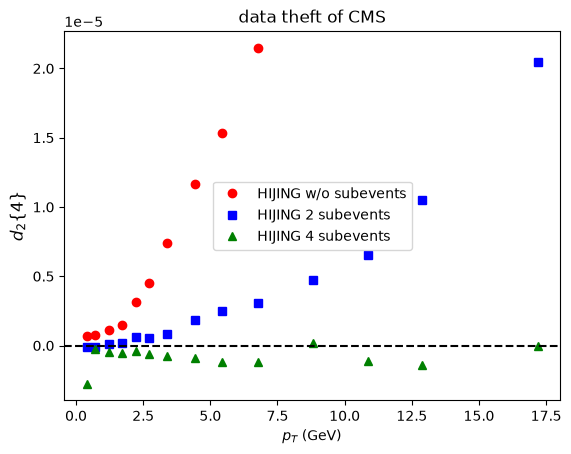

In [12]:
#note that manual inspection of the points reveals that teh first point is not right for the green triangles. 
'''import pandas as pd
import matplotlib.pyplot as plt

CMS_data = pd.read_csv("saved_runs/CMS_plot.csv")  

fig, ax = plt.subplots() 
CMS_nosub = CMS_data['HIJING_wo_subevents_red_filled_circle']*10**(-3) #the 10^-3 is to have the same scale as the plott 
CMS_4sub = CMS_data['HIJING_4subevents_green_filled_triangle']*10**(-3) #the 10^-3 is to have the same scale as the plot
ax.plot(CMS_data['pT_GeV_red'], CMS_nosub,
        'o', color='red', label='HIJING w/o subevents')
ax.plot(CMS_data['pT_GeV_green'], CMS_4sub,
        '^', color='green', label='HIJING 4 subevents')
ax.axhline(0, color='black', linestyle='--') 
ax.set_xlabel('$p_T$ (GeV)')
ax.set_ylabel(r'd$_2$\{4\} ')
ax.legend()
plt.show()'''

import pandas as pd
import matplotlib.pyplot as plt

CMS_data = pd.read_csv("filled_series_wide.csv")

fig, ax = plt.subplots()
CMS_0sub = CMS_data['HIJING_wo_subevents_red_filled_circle'].to_numpy()*10**(-3)
CMS_2sub = CMS_data['HIJING_2subevents_blue_filled_square'].to_numpy()*10**(-3)
CMS_4sub = CMS_data['HIJING_4subevents_green_filled_triangle'].to_numpy()*10**(-3)
ax.plot(CMS_data['pT_GeV_red'], CMS_0sub,
        'o', color='red', label='HIJING w/o subevents')
ax.plot(CMS_data['pT_GeV_blue'], CMS_2sub, 
        's', color='blue', label='HIJING 2 subevents')
ax.plot(CMS_data['pT_GeV_green'], CMS_4sub,
        '^', color='green', label='HIJING 4 subevents')
ax.set_ylabel("$d_2\\{4\\}$", fontsize = 12) 
ax.set_title("data theft of CMS")

ax.axhline(0, color='black', linestyle='--')
ax.set_xlabel('$p_T$ (GeV)')
#ax.set_ylabel(r'$d_2\\{4\\} (\times10^{-3})$') 
ax.legend() 
plt.show()   

In [ ]:
bin_size = 1 
n=2
# base_string="nudge_PPb"  
end_cols = 11 
#mult_range = [100, 200 ]   
mult_range = [0, 11000 ]    

cn4e0 = np.zeros(100) 
cn4stde0 = np.zeros(100)
cn2e0 = np.zeros(100)
cn2stde0 = np.zeros(100) 
 
dn4e0 = np.zeros(100)  
dn4stde0 = np.zeros(100)
dn2e0 = np.zeros(100)
dn2stde0 = np.zeros(100)  
dn2e2 = np.zeros(100)
dn2stde2 = np.zeros(100)  
dn2e4 = np.zeros(100)
dn2stde4 = np.zeros(100)  

dn4e4 = np.zeros(100)
dn4stde4 = np.zeros(100)


# dn4e2 = np.zeros(100)
# dn4stde2 = np.zeros(100)

pt_bins = np.zeros(100) 

#CMS_pt = CMS_data['pT_GeV_green'].to_numpy() 
CMS_pt = np.array([ 0.402,  0.713,  1.213,  1.717,  2.219,  2.718,  3.396,  4.414,
         5.426])#,  6.766,  8.82 , 10.86] )
#CMS_pt = np.array([  0.402,  0.713,  1.213,  1.717,  2.219,  2.718,  3.396,  4.414, 5.426,  6.766,])  #8.82 , 10.86, 12.5] )

POI_PT_EDGES = np.array([0.3, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 6.0, 8.0]) 
# POI_PT_EDGES = np.array([0.3, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 6.0, 8.0, 10, 12, 14, 20]) 
# POI_PT_MEAN = np.array(
#     [0.402, 0.713, 1.213, 1.717, 2.219, 2.718, 3.396, 4.414,
#      5.426, 6.766, 8.82, 10.86, 12.881, 17.188]
# )
# POI_PT_EDGES = np.array([0.3, 0.5, 1.0])  
POI_PT_MEAN = np.array([0.402, 0.713, 1.213, 1.717, 2.219, 2.718, 3.396, 4.414,5.426, 6.766, 8.82, 10.86, 12.881, 17.188])
CMS_pt = POI_PT_EDGES   
for i in range(0, len(CMS_pt)-1): 
    POI_start = CMS_pt[i] 
    #?
    POI_end = CMS_pt[i+1]

    results = pt_binning(testing12, mult_range, n, POI_start=POI_start, POI_end = POI_end,  momentum_cut=0, nudge=False) 
    #print(results)
    #print(POI_start)
  
    dn4e4[i] = results[0]
    dn4stde4[i] = results[1]#/np.sqrt(20) 

    dn4e0[i] = results[2]
    dn4stde0[i] = results[3]#/np.sqrt(20)
    dn2e0[i] = results[4]
    dn2stde0[i] = results[5]#/np.sqrt(20)
    
    cn4e0[i] = results[6]
    cn4stde0[i] = results[7]#/np.sqrt(20)
    cn2e0[i] = results[8]
    cn2stde0[i] = results[9]#/np.sqrt(20)

    dn2e2[i] = results[10]
    dn2stde2[i] = results[11]#/np.sqrt(20)

    dn2e4[i] = results[12]
    dn2stde4[i] = results[13]#/np.sqrt(20)

    # fcn4e0[i] = results[10]
    # fcn4stde0[i] = results[11]#/np.sqrt(20)
    # fcn2e0[i] = results[12]
    # fcn2stde0[i] = results[13]#/np.sqrt(20)

    # dn4e2[i] = results[10]
    # dn4stde2[i] = results[11]#/np.sqrt(20)

    pt_bins[i] = POI_PT_MEAN[i]

dn4e4 = np.trim_zeros(dn4e4)
dn4stde4 = np.trim_zeros(dn4stde4)

# dn4e2 = np.trim_zeros(dn4e2)
# dn4stde2 = np.trim_zeros(dn4stde2) 

dn4e0 = np.trim_zeros(dn4e0)
dn4stde0 = np.trim_zeros(dn4stde0)
dn2e0 = np.trim_zeros(dn2e0) 
dn2stde0 = np.trim_zeros(dn2stde0)
dn2e2 = np.trim_zeros(dn2e2) 
dn2stde2 = np.trim_zeros(dn2stde2) 
dn2e4 = np.trim_zeros(dn2e4) 
dn2stde4 = np.trim_zeros(dn2stde4) 

cn4e0 = np.trim_zeros(cn4e0)
cn4stde0 = np.trim_zeros(cn4stde0)
cn2e0 = np.trim_zeros(cn2e0)
cn2stde0 = np.trim_zeros(cn2stde0)

pt_bins = np.trim_zeros(pt_bins)

arrays_dataframe = {
        "cn4e0": cn4e0,
        "cn4stde0": cn4stde0,
        "cn2e0": cn2e0,
        "cn2stde0": cn2stde0,
        "dn4e0": dn4e0,
        "dn4stde0": dn4stde0, 
        "dn2e0": dn2e0,
        "dn2stde0": dn2stde0,
        "dn4e4": dn4e4,
        "dn4stde4": dn4stde4,
        "dn2e2": dn2e2,
        "dn2stde2": dn2stde2, 
        "dn2e4": dn2e4 ,
        "dn2stde4": dn2stde4,
        # "dn4e2": dn4e2,
        # "dn4stde2": dn4stde2, 
        "pt_bins": pt_bins
    
    }
arrays_dataframe          


# Create a DataFrame by aligning arrays by index (shorter ones become NaN)
df = pd.DataFrame(dict((k, pd.Series(v)) for k, v in arrays_dataframe.items()))
df.to_csv("pPb_isomerge_v205_10000Nparticles.csv", index=False)                   

#dn2e2_testing_ppiso_1       


100000
100000


In [ ]:
	dn4e0
1	-5.3859311386692096e-08
2	-2.539304148984029e-07
3	-4.154352242763825e-07
4	-2.753971062853181e-07
5	-2.762871837157956e-07
6	1.7443073288577704e-06
7	1.9833401941293017e-06
8	5.855579216859983e-06
9	2.9019220780886e-06
10	1.1459578435036265e-05

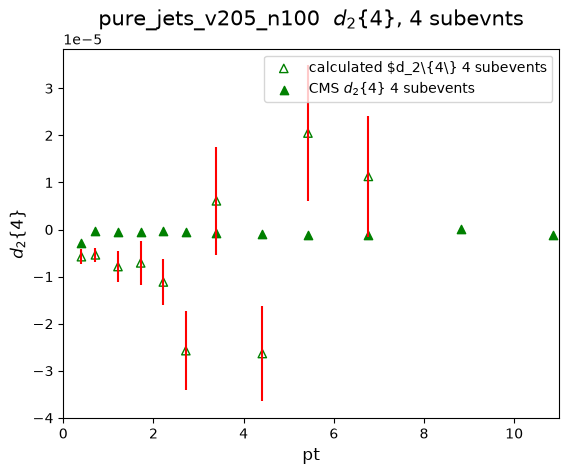

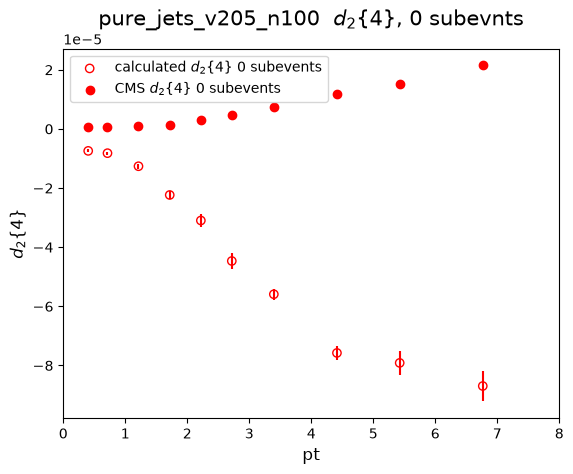

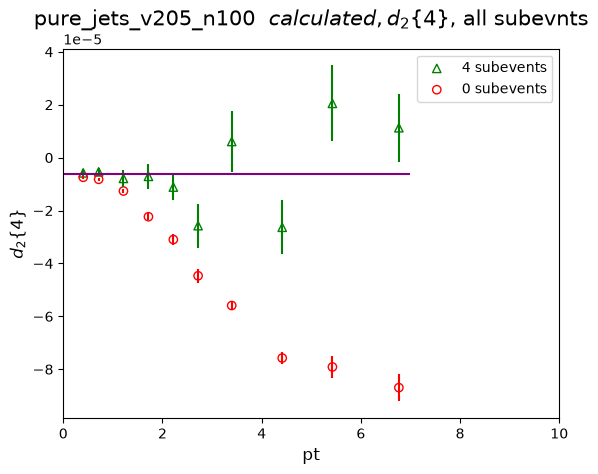

In [7]:
title_base = 'pure_jets_v205_n100  '  
x_label = 'pt' 

import matplotlib.pyplot as plt  
import numpy as np
import pandas as pd
cn4e0        = [[], []] 
cn4stde0     = [[], []] 
cn2e0        = [[], []] 
cn2stde0     = [[], []]
dn4e0        = [[], []] 
dn4stde0     = [[], []]
dn2e0        = [[], []]
dn2stde0     = [[], []] 
dn4e4        = [[], []] 
dn4stde4     = [[], []] 
dn4e2        = [[], []] 
dn4stde2     = [[], []] 


pt = [[], []]
#code that reads in hte saved values, was tested and makes the same plot, in different notebook .
for i in range(1):
    #momentum  = [0.0, 0.7]
    momentum  = [0.0]
    
    #df = pd.read_csv("testing_CSM_ptHijing_anaylsis.csv")
    df = pd.read_csv("pure_jets_v205_n100.csv")
    
    # Create separate NumPy arrays for each column
    cn4e0[i]        = df["cn4e0"       ].to_numpy()
    cn4stde0[i]     = df["cn4stde0"    ].to_numpy()
    cn2e0[i]       = df["cn2e0"       ].to_numpy()
    cn2stde0[i]     = df["cn2stde0"    ].to_numpy()
    dn4e0[i]        = df["dn4e0"       ].to_numpy()
    dn4stde0[i]     = df["dn4stde0"    ].to_numpy()
    dn2e0[i]       = df["dn2e0"       ].to_numpy()
    dn2stde0[i]     = df["dn2stde0"    ].to_numpy()
    dn4e4[i]        = df["dn4e4"       ].to_numpy()
    dn4stde4[i]     = df["dn4stde4"    ].to_numpy()
    # dn4e2[i]        = df["dn4e2"       ].to_numpy()
    # dn4stde2[i]     = df["dn4stde2"    ].to_numpy() 
    pt[i]  = df["pt_bins"].to_numpy()
#pt[0] = np.array([0.402, 0.713, 1.213, 1.717, 2.219, 2.718, 3.396, 4.414, 5.426, 6.766, 8.82, 10.86, 12.881])
#print(dn4e4[0])
plt.figure(0)
plt.scatter(pt[0], dn4e4[0],  marker='^',  facecolors='none',edgecolors='green', label = 'calculated $d_2\\{4\\} 4 subevents') #minbias
plt.errorbar(pt[0], dn4e4[0],  yerr=dn4stde4[0] , ecolor='red', linestyle='none')
plt.scatter(CMS_data['pT_GeV_green'], CMS_4sub , marker = '^', color = 'green', label = 'CMS $d_2\\{4\\}$ 4 subevents') #minbias
# plt.errorbar(pt[0], dn4e4[0],  yerr=dn4stde4[0] , ecolor='red', linestyle='none')
plt.xlim(0, 11)
#plt.ylim(-.00005, .0001)
plt.title(title_base+'$d_2\\{4\\}$, 4 subevnts', fontsize = 15)
plt.ylabel("$d_2\\{4\\}$", fontsize = 12) 
plt.xlabel(x_label, fontsize = 12)   
plt.legend() 

# plt.figure(2)
# plt.scatter(pt[0], dn4e2[0],  marker='s',  facecolors='none',edgecolors='blue', label = 'calculated $d_2\\{4\\} 2 subevents') #minbias
# plt.errorbar(pt[0], dn4e2[0],  yerr=dn4stde2[0] , ecolor='red', linestyle='none')
# plt.scatter(CMS_data['pT_GeV_blue'],CMS_2sub, marker = 's', color = 'blue', label = 'CMS $d_2\\{4\\}$ 2 subevents') #minbias
# # plt.errorbar(pt[0], dn4e4[0],  yerr=dn4stde4[0] , ecolor='red', linestyle='none')
# plt.xlim(0, 11)
# #plt.ylim(-.00005, .0001)
# plt.title(title_base+'$d_2\\{4\\}$, 2 subevnts', fontsize = 15)
# plt.ylabel("$d_2\\{4\\}$", fontsize = 12) 
# plt.xlabel(x_label, fontsize = 12)   
# plt.legend() 

plt.figure(1)
plt.scatter(pt[0], dn4e0[0],  marker='o',  facecolors='none',edgecolors='red', label = 'calculated $d_2\\{4\\}$ 0 subevents') #minbias
plt.errorbar(pt[0], dn4e0[0],  yerr=dn4stde0[0] , ecolor='red', linestyle='none')
plt.scatter(CMS_data['pT_GeV_red'], CMS_0sub, marker = 'o', color = 'red', label = 'CMS $d_2\\{4\\}$ 0 subevents') #CMS  
#old dn4e0 without the weights
# xx = [1,2,3,4,5,6,7]
# yyy = [-4.339150690482422e-05, -4.0682355383022836e-05, -3.4723915297962205e-05, -3.7009292040129205e-05, -2.3049754078975517e-05, -4.469431464210346e-05, -1.174165864141442e-05]
# plt.scatter(xx, yyy,marker='o',  facecolors='none',edgecolors='red', label = 'calculated $d_2\\{4\\}$ 0 subevents, no weights')
# plt.errorbar(pt[0], dn4e4[0],  yerr=dn4stde4[0] , ecolor='red', linestyle='none')
plt.xlim(0, 8)
#plt.ylim(-.5*10**(-5), 4*10**(-5))
plt.title(title_base+'$d_2\\{4\\}$, 0 subevnts', fontsize = 15)
plt.ylabel("$d_2\\{4\\}$", fontsize = 12) 
plt.xlabel(x_label, fontsize = 12)   
plt.legend()

plt.figure(3)
plt.scatter(pt[0], dn4e4[0],  marker='^',  facecolors='none',edgecolors='green', label = '4 subevents') #minbias
plt.errorbar(pt[0], dn4e4[0],  yerr=dn4stde4[0] , ecolor='green', linestyle='none')

'''plt.scatter(pt[0], dn4e2[0],  marker='s',  facecolors='none',edgecolors='blue', label = '2 subevents') #minbias
plt.errorbar(pt[0], dn4e2[0],  yerr=dn4stde2[0] , ecolor='red', linestyle='none')'''

plt.scatter(pt[0], dn4e0[0],  marker='o',  facecolors='none',edgecolors='red', label = '0 subevents') #minbias
plt.errorbar(pt[0], dn4e0[0],  yerr=dn4stde0[0] , ecolor='red', linestyle='none')
plt.xlim(0, 10) 
#plt.ylim(-.00005, .00005)
plt.title(title_base+'$calculated, d_2\\{4\\}$, all subevnts', fontsize = 15)
plt.hlines(y= -.05**4, xmin = 0, xmax = 7,color = 'purple')
plt.ylabel("$d_2\\{4\\}$", fontsize = 12)  
plt.xlabel(x_label, fontsize = 12)   
plt.legend() 

plt.figure(4)
plt.scatter(pt[0], dn2e2[0],  marker='^',  facecolors='none',edgecolors='green', label = '4 subevents') #minbias
plt.errorbar(pt[0], dn2e2[0],  yerr=dn2stde2[0] , ecolor='green', linestyle='none')

'''plt.scatter(pt[0], dn4e2[0],  marker='s',  facecolors='none',edgecolors='blue', label = '2 subevents') #minbias
plt.errorbar(pt[0], dn4e2[0],  yerr=dn4stde2[0] , ecolor='red', linestyle='none')'''

plt.scatter(pt[0], dn2e0[0],  marker='o',  facecolors='none',edgecolors='red', label = '0 subevents') #minbias
plt.errorbar(pt[0], dn2e0[0],  yerr=dn2stde0[0] , ecolor='red', linestyle='none')
plt.xlim(0, 10) 
#plt.ylim(-.00005, .00005)
plt.title(title_base+'$calculated, d_2\\{2\\}$, all subevnts', fontsize = 15)
plt.hlines(y= .05**2, xmin = 0, xmax = 7,color = 'purple')
plt.ylabel("$d_2\\{2\\}$", fontsize = 12)  
plt.xlabel(x_label, fontsize = 12)   
plt.legend() 
# plt.figure(4)
# plt.scatter(pt[0], -dn4e0[0]/(abs(cn4e0[0]))**(3/4),  marker='o',  facecolors='none',edgecolors='red', label = r"$v_2\{4'\}$") #
# plt.scatter(pt[0], (abs(cn4e0[0]))**(1/4),  marker='o',  color = 'red', label = '$v_2\\{4\\}$')
# plt.scatter(pt[0], -dn2e0[0]/(cn2e0[0])**(1/2),  marker='^',  facecolors='none',edgecolors='blue', label = r"$v_2\{2'\}$") #
# plt.scatter(pt[0], (cn4e0[0])**(1/2),  marker='^',  color ='blue', label = '$v_2\\{2\\}$')


# plt.xlim(0, 8)
# #plt.ylim(-.5*10**(-5), 4*10**(-5))
# plt.title(title_base+'$v_2$, 0 subevnts', fontsize = 15)
# plt.ylabel("$v_2$", fontsize = 12) 
# plt.xlabel(x_label, fontsize = 12)   
# plt.legend()

In [4]:
.05**4

6.250000000000001e-06

for pp+ 100 iso particles, difference between pp eta and p-Pb eta
dif of 0 subevents: [-3.04319589e-07 -4.24029574e-07 -6.58978411e-07 -4.56625265e-07
 -5.37769262e-07 -1.16843011e-06 -9.65393395e-07  2.74805173e-07
  3.59013316e-06  2.15057989e-06]
dif of 4 subevents: [ 6.58419476e-07  4.08353770e-07  1.10416618e-08 -9.92811387e-07
  1.83124516e-06 -3.81623561e-07 -8.91860744e-07 -2.16071345e-06
  8.86447092e-06 -1.44317842e-05]


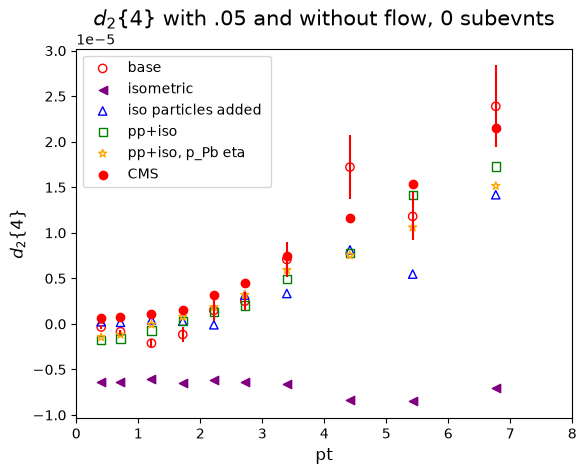

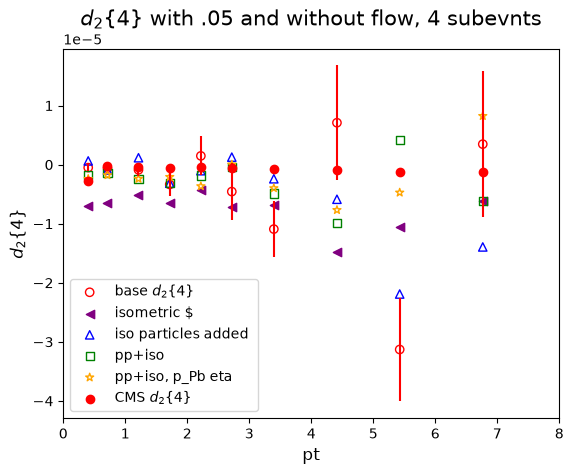

In [13]:
import matplotlib.pyplot as plt
import numpy as np 
#title_base = '4Mmult[100, 200],p-Pb '
x_label = 'pt'
import pandas as pd

df = pd.read_csv("4Mmult[100, 200],p-Pb.csv")
dn4e0        = df["dn4e0"].to_numpy()
dn4stde0     = df["dn4stde0"].to_numpy()
dn4e4        = df["dn4e4" ].to_numpy()
dn4stde4     = df["dn4stde4" ].to_numpy()
pt   = df["pt_bins"].to_numpy()

# df = pd.read_csv("v2_.01, mult[100, 200],p-Pb,1M.csv")
# n01dn4e0        = df["dn4e0"].to_numpy()
# n01dn4stde0     = df["dn4stde0"].to_numpy()
# n01dn4e4        = df["dn4e4" ].to_numpy()
# n01dn4stde4     = df["dn4stde4" ].to_numpy()

df = pd.read_csv("v2_.05, mult[100, 200],p-Pb,1M.csv")
n05dn4e0        = df["dn4e0"].to_numpy() 
n05dn4stde0     = df["dn4stde0"].to_numpy()
n05dn4e4        = df["dn4e4" ].to_numpy()
n05dn4stde4     = df["dn4stde4" ].to_numpy() 

df = pd.read_csv("v2_.1, mult[100, 200],p-Pb,1M.csv")
n1dn4e0        = df["dn4e0"].to_numpy()
n1dn4stde0     = df["dn4stde0"].to_numpy()
n1dn4e4        = df["dn4e4" ].to_numpy()
n1dn4stde4     = df["dn4stde4" ].to_numpy()  

df = pd.read_csv("Iso.05mult[100, 200],p-Pb.csv") 
iso05dn4e0        = df["dn4e0"].to_numpy()
iso05dn4stde0     = df["dn4stde0"].to_numpy()
iso05dn4e4        = df["dn4e4" ].to_numpy()
iso05dn4stde4     = df["dn4stde4" ].to_numpy() 

df = pd.read_csv("halfhalfIso.05mult[100, 200].csv") #this is with the p_pb data and 50 particles of iso 
partiso05dn4e0        = df["dn4e0"].to_numpy()
partiso05dn4stde0     = df["dn4stde0"].to_numpy()
partiso05dn4e4        = df["dn4e4" ].to_numpy()
partiso05dn4stde4     = df["dn4stde4" ].to_numpy()  

df = pd.read_csv("pp_isomerge_all.csv")
ppisodn4e0        = df["dn4e0"].to_numpy()
ppisodn4stde0     = df["dn4stde0"].to_numpy()
ppisodn4e4        = df["dn4e4" ].to_numpy()
ppisodn4stde4     = df["dn4stde4" ].to_numpy()  

df = pd.read_csv("pp_isomerge_all_etapPb.csv")
ppisoetadn4e0        = df["dn4e0"].to_numpy()
ppisoetadn4stde0     = df["dn4stde0"].to_numpy()
ppisoetadn4e4        = df["dn4e4" ].to_numpy()
ppisoetadn4stde4     = df["dn4stde4" ].to_numpy()  

plt.figure(1)
plt.scatter(pt, dn4e0,  marker='o',  facecolors='none',edgecolors='red', label = 'base ') #minbias
plt.errorbar(pt, dn4e0,  yerr=dn4stde0 , ecolor='red', linestyle='none')
#plt.scatter(pt, n01dn4e0,  marker='^',  facecolors='none',edgecolors='blue', label = 'flow .01 ') #minbias
#plt.scatter(pt, n05dn4e0,  marker='s',  facecolors='none',edgecolors='green', label = 'nudge flow') #minbias
plt.scatter(pt, iso05dn4e0,  marker='<',  color = 'purple' , label = 'isometric ') #minbias 
plt.scatter(pt, partiso05dn4e0,  marker='^',  facecolors='none',edgecolors='blue', label = 'iso particles added ')
plt.scatter(pt, ppisodn4e0, marker='s',  facecolors='none',edgecolors='green', label = 'pp+iso ')
plt.scatter(pt, ppisoetadn4e0,  marker='*',  facecolors='none',edgecolors='orange', label = 'pp+iso, p_Pb eta ')
#plt.scatter(pt, n1dn4e0,  marker='*',  facecolors='none',edgecolors='orange', label = 'flow .1 $d_2\\{4\\}$') #minbias
plt.scatter(CMS_data['pT_GeV_red'], CMS_0sub, marker = 'o', color = 'red', label = 'CMS ') #CMS  

plt.xlim(0, 8)
#plt.ylim(-.5*10**(-5), 4*10**(-5))
plt.title('$d_2\\{4\\}$ with .05 and without flow, 0 subevnts', fontsize = 15)
plt.ylabel("$d_2\\{4\\}$", fontsize = 12) 
plt.xlabel(x_label, fontsize = 12)   
plt.legend() 

plt.figure(0)
plt.scatter(pt, dn4e4,  marker='o',  facecolors='none',edgecolors='red', label = 'base $d_2\\{4\\}$') #minbias
plt.errorbar(pt, dn4e4,  yerr=dn4stde4 , ecolor='red', linestyle='none')
#plt.scatter(pt, n01dn4e4,  marker='^',  facecolors='none',edgecolors='blue', label = 'flow .01 $d_2\\{4\\}$') #minbias
#plt.scatter(pt, n05dn4e4,  marker='s',  facecolors='none',edgecolors='green', label = 'nudge flow $') #minbias
plt.scatter(pt, iso05dn4e4,  marker='<',  color = 'purple' , label = 'isometric $') #minbias
plt.scatter(pt, partiso05dn4e4,  marker='^',  facecolors='none',edgecolors='blue', label = 'iso particles added ')
plt.scatter(pt, ppisodn4e4, marker='s',  facecolors='none',edgecolors='green', label = 'pp+iso ')
plt.scatter(pt, ppisoetadn4e4,  marker='*',  facecolors='none',edgecolors='orange', label = 'pp+iso, p_Pb eta ')
#plt.scatter(pt, n1dn4e4,  marker='*',  facecolors='none',edgecolors='orange', label = 'flow .1 $d_2\\{4\\}$') #minbias
plt.scatter(CMS_data['pT_GeV_green'], CMS_4sub, marker = 'o', color = 'red', label = 'CMS $d_2\\{4\\}$') #CMS  

plt.xlim(0, 8)
#plt.ylim(-.5*10**(-5), 4*10**(-5))
plt.title('$d_2\\{4\\}$ with .05 and without flow, 4 subevnts', fontsize = 15)
plt.ylabel("$d_2\\{4\\}$", fontsize = 12) 
plt.xlabel(x_label, fontsize = 12)   
plt.legend()  
print('for pp+ 100 iso particles, difference between pp eta and p-Pb eta')
print('dif of 0 subevents:',ppisodn4e0-ppisoetadn4e0 )
print('dif of 4 subevents:',ppisodn4e4-ppisoetadn4e4 )

In [ ]:
	cn4e0	cn4stde0	cn2e0	cn2stde0	dn4e0
1	-9.671408592328027e-07	8.962460801349885e-08	0.002350713880597549	6.154434557759245e-06	-1.4582775230067313e-06 pp mix with iso .05

	cn4e0	cn4stde0	cn2e0	cn2stde0	dn4e0
1	-6.332175179274509e-06	1.394256222066991e-07	0.002510145297183995	7.934429910010158e-06	-6.398453593685566e-06 pure iso .05

	cn4e0	cn4stde0	cn2e0	cn2stde0	dn4e0
1	-2.8850408975549617e-05	2.3771172096718136e-07	0.006207411521201779	1.0181468876116508e-05	-2.9942157574452126e-05 pp mix with iso .1

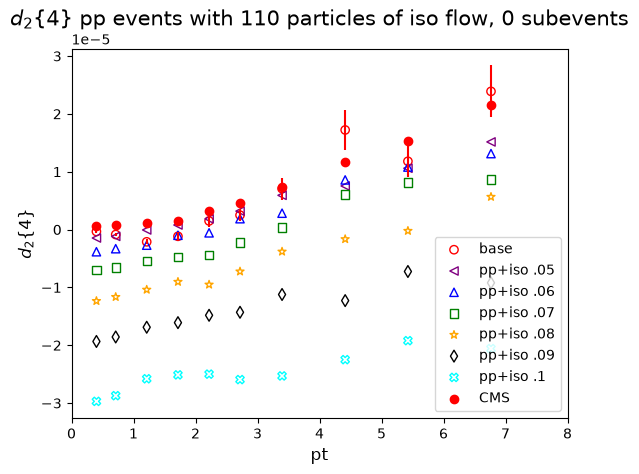

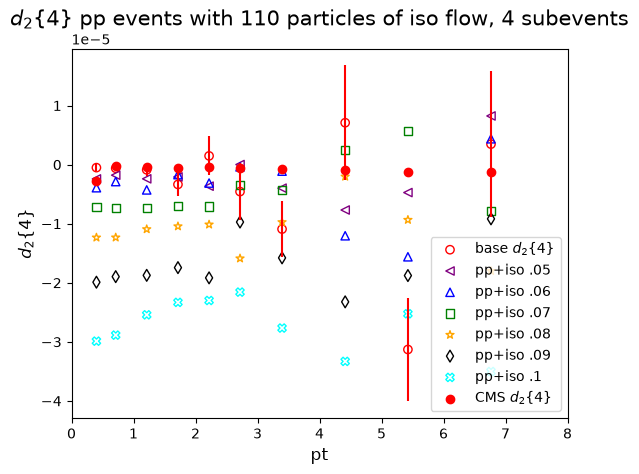

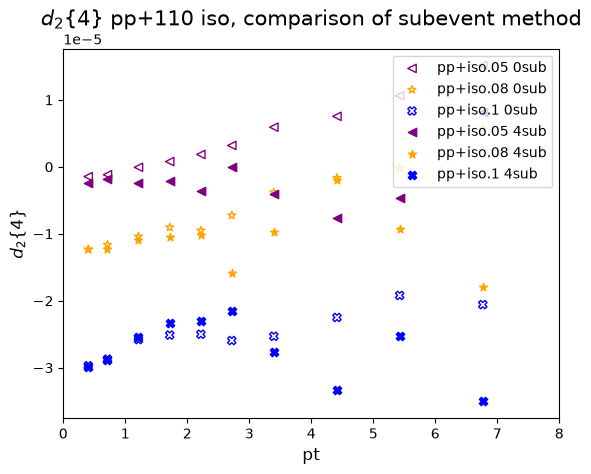

In [9]:
import matplotlib.pyplot as plt
import numpy as np  
#title_base = '4Mmult[100, 200],p-Pb '
x_label = 'pt'
import pandas as pd

df = pd.read_csv("4Mmult[100, 200],p-Pb.csv")
dn4e0        = df["dn4e0"].to_numpy()
dn4stde0     = df["dn4stde0"].to_numpy()
dn4e4        = df["dn4e4" ].to_numpy()
dn4stde4     = df["dn4stde4" ].to_numpy()
pt   = df["pt_bins"].to_numpy()

# df = pd.read_csv("halfhalfIso.05mult[100, 200].csv") #this is with the p_pb data and 50 particles of iso
# partiso05dn4e0        = df["dn4e0"].to_numpy()
# partiso05dn4stde0     = df["dn4stde0"].to_numpy()
# partiso05dn4e4        = df["dn4e4" ].to_numpy()
# partiso05dn4stde4     = df["dn4stde4" ].to_numpy()  

df = pd.read_csv("pp_isomerge_all_etapPb.csv") #v2 .05
ppisov205dn4e0        = df["dn4e0"].to_numpy()
ppisov205dn4stde0     = df["dn4stde0"].to_numpy()
ppisov205dn4e4        = df["dn4e4" ].to_numpy()
ppisov205dn4stde4     = df["dn4stde4" ].to_numpy()  

df = pd.read_csv("pp_isomerge_v206.csv")
ppisov206dn4e0        = df["dn4e0"].to_numpy()
ppisov206dn4stde0     = df["dn4stde0"].to_numpy()
ppisov206dn4e4        = df["dn4e4" ].to_numpy()
ppisov206dn4stde4     = df["dn4stde4" ].to_numpy() 

df = pd.read_csv("pp_isomerge_v207.csv")
ppisov207dn4e0        = df["dn4e0"].to_numpy()
ppisov207dn4stde0     = df["dn4stde0"].to_numpy()
ppisov207dn4e4        = df["dn4e4" ].to_numpy()
ppisov207dn4stde4     = df["dn4stde4" ].to_numpy() 

df = pd.read_csv("pp_isomerge_v208.csv")
ppisov208dn4e0        = df["dn4e0"].to_numpy()
ppisov208dn4stde0     = df["dn4stde0"].to_numpy()
ppisov208dn4e4        = df["dn4e4" ].to_numpy()
ppisov208dn4stde4     = df["dn4stde4" ].to_numpy() 

df = pd.read_csv("pp_isomerge_v209.csv")
ppisov209dn4e0        = df["dn4e0"].to_numpy()
ppisov209dn4stde0     = df["dn4stde0"].to_numpy()
ppisov209dn4e4        = df["dn4e4" ].to_numpy()
ppisov209dn4stde4     = df["dn4stde4" ].to_numpy() 

df = pd.read_csv("pp_isomerge_v21_all.csv")
ppisov21dn4e0        = df["dn4e0"].to_numpy()
ppisov21dn4stde0     = df["dn4stde0"].to_numpy()
ppisov21dn4e4        = df["dn4e4" ].to_numpy()
ppisov21dn4stde4     = df["dn4stde4" ].to_numpy() 

plt.figure(1)
plt.scatter(pt, dn4e0,  marker='o',  facecolors='none',edgecolors='red', label = 'base ') #minbias
plt.errorbar(pt, dn4e0,  yerr=dn4stde0 , ecolor='red', linestyle='none')
plt.scatter(pt, ppisov205dn4e0,  marker='<', facecolors='none',edgecolors='purple' , label = 'pp+iso .05')
plt.scatter(pt, ppisov206dn4e0,  marker='^',  facecolors='none',edgecolors='blue' , label = 'pp+iso .06') 
plt.scatter(pt, ppisov207dn4e0,  marker='s',  facecolors='none',edgecolors='green' , label = 'pp+iso .07')
plt.scatter(pt, ppisov208dn4e0,  marker='*', facecolors='none',edgecolors='orange' , label = 'pp+iso .08')
plt.scatter(pt, ppisov209dn4e0,  marker='d',  facecolors='none',edgecolors='black', label = 'pp+iso .09')
plt.scatter(pt, ppisov21dn4e0,  marker='X',  facecolors='none',edgecolors='cyan' , label = 'pp+iso .1')
plt.scatter(CMS_data['pT_GeV_red'], CMS_0sub, marker = 'o', color = 'red', label = 'CMS ') #CMS  

plt.xlim(0, 8)
#plt.ylim(-.5*10**(-5), 4*10**(-5))
plt.title('$d_2\\{4\\}$ pp events with 110 particles of iso flow, 0 subevents', fontsize = 15)
plt.ylabel("$d_2\\{4\\}$", fontsize = 12) 
plt.xlabel(x_label, fontsize = 12)   
plt.legend() 

plt.figure(0)
plt.scatter(pt, dn4e4,  marker='o',  facecolors='none',edgecolors='red', label = 'base $d_2\\{4\\}$') #minbias
plt.errorbar(pt, dn4e4,  yerr=dn4stde4 , ecolor='red', linestyle='none')
plt.scatter(pt, ppisov205dn4e4,  marker='<', facecolors='none',edgecolors='purple' , label = 'pp+iso .05')
plt.scatter(pt, ppisov206dn4e4,  marker='^',  facecolors='none',edgecolors='blue' , label = 'pp+iso .06') 
plt.scatter(pt, ppisov207dn4e4,  marker='s',  facecolors='none',edgecolors='green' , label = 'pp+iso .07')
plt.scatter(pt, ppisov208dn4e4,  marker='*', facecolors='none',edgecolors='orange' , label = 'pp+iso .08')
plt.scatter(pt, ppisov209dn4e4,  marker='d',  facecolors='none',edgecolors='black', label = 'pp+iso .09')
plt.scatter(pt, ppisov21dn4e4,  marker='X',  facecolors='none',edgecolors='cyan' , label = 'pp+iso .1')
plt.scatter(CMS_data['pT_GeV_green'], CMS_4sub, marker = 'o', color = 'red', label = 'CMS $d_2\\{4\\}$') #CMS  

plt.xlim(0, 8)
#plt.ylim(-.5*10**(-5), 4*10**(-5))
plt.title('$d_2\\{4\\}$ pp events with 110 particles of iso flow, 4 subevents', fontsize = 15)
plt.ylabel("$d_2\\{4\\}$", fontsize = 12) 
plt.xlabel(x_label, fontsize = 12)   
plt.legend()   

plt.figure(2)
# plt.scatter(pt, dn4e0,  marker='o',  facecolors='none',edgecolors='red', label = 'base 0sub') #minbias
#plt.errorbar(pt, dn4e0,  yerr=dn4stde0 , ecolor='red', linestyle='none')
plt.scatter(pt, ppisov205dn4e0,  marker='<', facecolors='none',edgecolors='purple' , label = 'pp+iso.05 0sub')
#plt.scatter(pt, ppisov206dn4e0,  marker='^',  facecolors='none',edgecolors='blue' , label = 'pp+iso .06') 
#plt.scatter(pt, ppisov207dn4e0,  marker='s',  facecolors='none',edgecolors='green' , label = 'pp+iso .07')
plt.scatter(pt, ppisov208dn4e0,  marker='*', facecolors='none',edgecolors='orange' , label = 'pp+iso.08 0sub')
#plt.scatter(pt, ppisov209dn4e0,  marker='d',  facecolors='none',edgecolors='black', label = 'pp+iso .09')
plt.scatter(pt, ppisov21dn4e0,  marker='X',  facecolors='none',edgecolors='blue' , label = 'pp+iso.1 0sub')
#plt.scatter(CMS_data['pT_GeV_red'], CMS_0sub, marker = 'o', color = 'red', label = 'CMS 0sub') #CMS  

#plt.scatter(pt, dn4e4,  marker='o',  color='red', label = 'base 4sub') #minbias
#plt.errorbar(pt, dn4e4,  yerr=dn4stde4 , ecolor='red', linestyle='none')
plt.scatter(pt, ppisov205dn4e4,  marker='<',color='purple' , label = 'pp+iso.05 4sub')
#plt.scatter(pt, ppisov206dn4e4,  marker='^',  facecolors='none',edgecolors='blue' , label = 'pp+iso .06') 
#plt.scatter(pt, ppisov207dn4e4,  marker='s',  facecolors='none',edgecolors='green' , label = 'pp+iso .07')
plt.scatter(pt, ppisov208dn4e4,  marker='*', color='orange' , label = 'pp+iso.08 4sub')
#plt.scatter(pt, ppisov209dn4e4,  marker='d',  facecolors='none',edgecolors='black', label = 'pp+iso .09')
plt.scatter(pt, ppisov21dn4e4,  marker='X', color='blue' , label = 'pp+iso.1 4sub')
#plt.scatter(CMS_data['pT_GeV_green'], CMS_4sub, marker = 'o', color = 'red', label = 'CMS 4sub') #CMS  

plt.xlim(0, 8)
#plt.ylim(-.5*10**(-5), 4*10**(-5))
plt.title('$d_2\\{4\\}$ pp+110 iso, comparison of subevent method', fontsize = 15)
plt.ylabel("$d_2\\{4\\}$", fontsize = 12) 
plt.xlabel(x_label, fontsize = 12)   
plt.legend() 
 

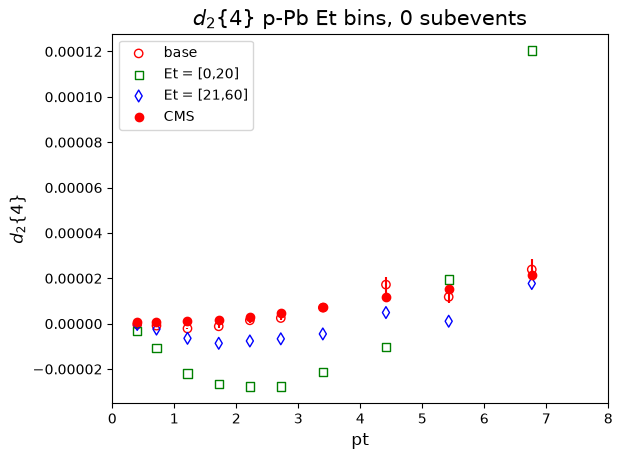

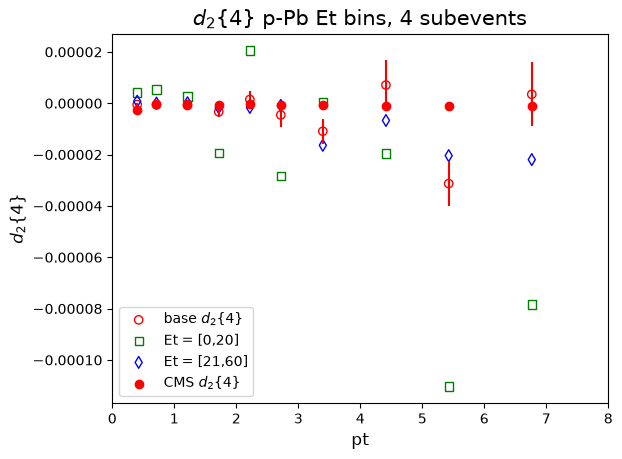

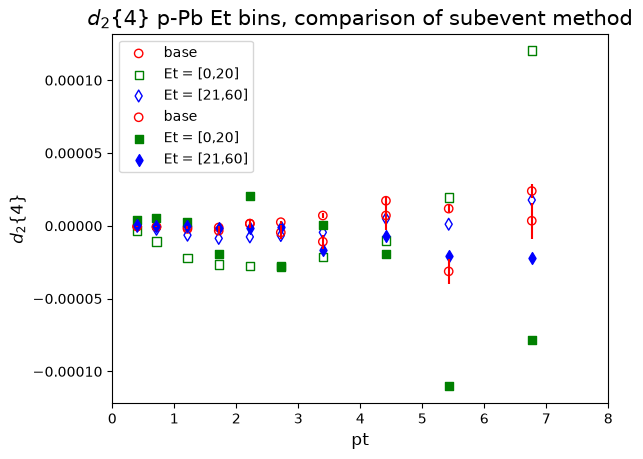

In [23]:
#Et plotingg
import matplotlib.pyplot as plt
import numpy as np 
#title_base = '4Mmult[100, 200],p-Pb '
x_label = 'pt'
import pandas as pd

df = pd.read_csv("4Mmult[100, 200],p-Pb.csv")
dn4e0        = df["dn4e0"].to_numpy()
dn4stde0     = df["dn4stde0"].to_numpy()
dn4e4        = df["dn4e4" ].to_numpy()
dn4stde4     = df["dn4stde4" ].to_numpy()
pt   = df["pt_bins"].to_numpy()

df = pd.read_csv("pPb_Et_0_20.csv") #v2 .05
ET1dn4e0        = df["dn4e0"].to_numpy()
ET1dn4stde0     = df["dn4stde0"].to_numpy()
ET1dn4e4        = df["dn4e4" ].to_numpy()
ET1dn4stde4     = df["dn4stde4" ].to_numpy()  

df = pd.read_csv("pPb_Et_21_60.csv")
ET2dn4e0        = df["dn4e0"].to_numpy()
ET2dn4stde0     = df["dn4stde0"].to_numpy()
ET2dn4e4        = df["dn4e4" ].to_numpy()
ET2dn4stde4     = df["dn4stde4" ].to_numpy() 



plt.figure(1)
plt.scatter(pt, dn4e0,  marker='o',  facecolors='none',edgecolors='red', label = 'base ') #minbias
plt.errorbar(pt, dn4e0,  yerr=dn4stde0 , ecolor='red', linestyle='none')
plt.scatter(pt, ET1dn4e0,  marker='s', facecolors='none',edgecolors='green' , label = 'Et = [0,20]')
plt.scatter(pt, ET2dn4e0,  marker='d',  facecolors='none',edgecolors='blue' , label = 'Et = [21,60]') 
plt.scatter(CMS_data['pT_GeV_red'], CMS_0sub, marker = 'o', color = 'red', label = 'CMS ') #CMS  

plt.xlim(0, 8)
#plt.ylim(-.5*10**(-5), 4*10**(-5))
plt.title('$d_2\\{4\\}$ p-Pb Et bins, 0 subevents', fontsize = 15)
plt.ylabel("$d_2\\{4\\}$", fontsize = 12) 
plt.xlabel(x_label, fontsize = 12)   
plt.legend() 

plt.figure(0)
plt.scatter(pt, dn4e4,  marker='o',  facecolors='none',edgecolors='red', label = 'base $d_2\\{4\\}$') #minbias
plt.errorbar(pt, dn4e4,  yerr=dn4stde4 , ecolor='red', linestyle='none')
plt.scatter(pt, ET1dn4e4,  marker='s', facecolors='none',edgecolors='green' , label = 'Et = [0,20]')
plt.scatter(pt, ET2dn4e4,  marker='d',  facecolors='none',edgecolors='blue' , label = 'Et = [21,60]') 
plt.scatter(CMS_data['pT_GeV_green'], CMS_4sub, marker = 'o', color = 'red', label = 'CMS $d_2\\{4\\}$') #CMS  

plt.xlim(0, 8)
#plt.ylim(-.5*10**(-5), 4*10**(-5))
plt.title('$d_2\\{4\\}$ p-Pb Et bins, 4 subevents', fontsize = 15)
plt.ylabel("$d_2\\{4\\}$", fontsize = 12) 
plt.xlabel(x_label, fontsize = 12)   
plt.legend()   

plt.figure(2)
plt.scatter(pt, dn4e0,  marker='o',  facecolors='none',edgecolors='red', label = 'base ') #minbias
plt.errorbar(pt, dn4e0,  yerr=dn4stde0 , ecolor='red', linestyle='none')
plt.scatter(pt, ET1dn4e0,  marker='s', facecolors='none',edgecolors='green' , label = 'Et = [0,20]')
plt.scatter(pt, ET2dn4e0,  marker='d',  facecolors='none',edgecolors='blue' , label = 'Et = [21,60]') 
#plt.scatter(CMS_data['pT_GeV_red'], CMS_0sub, marker = 'o', color = 'red', label = 'CMS ') #CMS  

plt.scatter(pt, dn4e4,  marker='o',  facecolors='none',edgecolors='red', label = 'base ') #minbias
plt.errorbar(pt, dn4e4,  yerr=dn4stde4 , ecolor='red', linestyle='none')
plt.scatter(pt, ET1dn4e4,  marker='s',color='green' , label = 'Et = [0,20]')
plt.scatter(pt, ET2dn4e4,  marker='d', color='blue' , label = 'Et = [21,60]') 
#plt.scatter(CMS_data['pT_GeV_green'], CMS_4sub, marker = 'o', color = 'red', label = 'CMS $d_2\\{4\\}$') #CMS  

plt.xlim(0, 8)
#plt.ylim(-.5*10**(-5), 4*10**(-5))
plt.title('$d_2\\{4\\}$ p-Pb Et bins, comparison of subevent method', fontsize = 15)
plt.ylabel("$d_2\\{4\\}$", fontsize = 12) 
plt.xlabel(x_label, fontsize = 12)   
plt.legend() 


In [107]:
CMS_data['pT_GeV_red']

0     0.402
1     0.713
2     1.213
3     1.717
4     2.219
5     2.718
6     3.396
7     4.414
8     5.426
9     6.766
10      NaN
11      NaN
12      NaN
13      NaN
Name: pT_GeV_red, dtype: float64

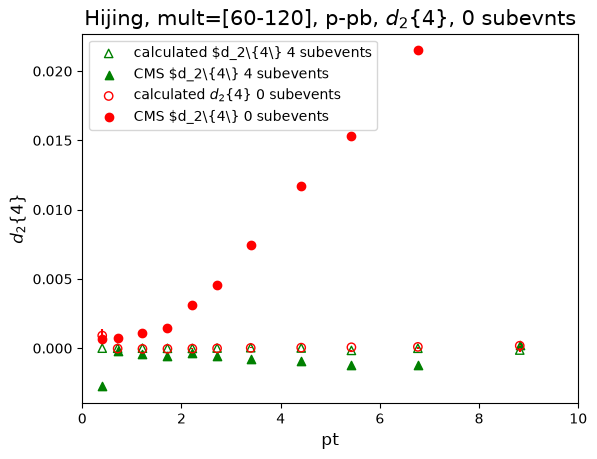

In [93]:
plt.figure(0)
plt.scatter(pt[0], dn4e4[0],  marker='^',  facecolors='none',edgecolors='green', label = 'calculated $d_2\\{4\\} 4 subevents') #minbias
plt.errorbar(pt[0], dn4e4[0],  yerr=dn4stde4[0] , ecolor='red', linestyle='none')
plt.scatter(CMS_data['pT_GeV_green'], CMS_data['HIJING_4subevents_green_filled_triangle'], marker = '^', color = 'green', label = 'CMS $d_2\\{4\\} 4 subevents') #minbias
# plt.errorbar(pt[0], dn4e4[0],  yerr=dn4stde4[0] , ecolor='red', linestyle='none')
plt.xlim(0, 10)
#plt.ylim(-.0001, .0001)


plt.title(title_base+'$d_2\\{4\\}$, 4 subevnts', fontsize = 15)
plt.ylabel("$d_2\\{4\\}$", fontsize = 12) 
plt.xlabel(x_label, fontsize = 12)   
plt.legend()

plt.scatter(pt[0], dn4e0[0],  marker='o',  facecolors='none',edgecolors='red', label = 'calculated $d_2\\{4\\}$ 0 subevents') #minbias
plt.errorbar(pt[0], dn4e0[0],  yerr=dn4stde0[0] , ecolor='red', linestyle='none')
plt.scatter(CMS_data['pT_GeV_red'], CMS_data['HIJING_wo_subevents_red_filled_circle'], marker = 'o', color = 'red', label = 'CMS $d_2\\{4\\} 0 subevents') #minbias
# plt.errorbar(pt[0], dn4e4[0],  yerr=dn4stde4[0] , ecolor='red', linestyle='none')
plt.xlim(0, 10)
#plt.ylim(-.0001, .0001)


plt.title(title_base+'$d_2\\{4\\}$, 0 subevnts', fontsize = 15)
plt.ylabel("$d_2\\{4\\}$", fontsize = 12) 
plt.xlabel(x_label, fontsize = 12)   
plt.legend()

In [ ]:
 CMS_pt = [0.4,
0.71,
1.21,
1.71,
2.22,
2.72,
3.4,
4.41,
5.43,
6.77,
8.81,
11.61,
16.42]
CMS_dn4e4 = [-8.74E-08,
-2.69E-07,
-6.89E-07,
-1.14E-06,
-1.57E-06,
-1.41E-06,
-1.32E-06,
-1.93E-06,
-1.42E-06,
-3.60E-07,
-2.13E-06,
-3.20E-07,
8.12E-10]

In [21]:
b = [
    [np.array_split(np.asarray(a[i]), 20)[k] for i in range(10)]
    for k in range(20)
] 


In [25]:
b[0][0]

array([-0.00153777, -0.00039278, -0.00259338])

In [ ]:
def weighted_average(values, weights, n_splits=20):
    values = np.asarray(values)
    weights = np.asarray(weights)
    
    # Remove invalid entries
    mask = values != 1234
    values = values[mask]
    weights = weights[mask]
    
    if len(values) == 0:
        return np.nan, np.nan
    
    # Split into approximately equal chunks
    value_chunks = np.array_split(values, n_splits)
    weight_chunks = np.array_split(weights, n_splits)
    
    chunk_avgs = []
    
    for v, w in zip(value_chunks, weight_chunks):
        if len(v) == 0:
            continue
        chunk_avgs.append(np.average(v, weights=w))
    
    chunk_avgs = np.asarray(chunk_avgs)
    
    return np.mean(chunk_avgs), np.std(chunk_avgs, ddof=1)/np.sqrt(20) #sqrt(20) is at the end 
def differential_cumulant4(dcor):
remove 1234 before the average. 

A1 = np.average(dcor[0], weights=dcor[1])
A2 = np.average(dcor[2], weights=dcor[3])
A3 = np.average(dcor[4], weights=dcor[5])
A4 = np.average(dcor[6], weights=dcor[7])
A5 = np.average(dcor[8], weights=dcor[9])

return A1 - A2*A3 - A4*A5

def combine_and_average(dcor4ae4, dcor4be4, dcor4ce4, dcor4de4):

    # Differential cumulant for each subevent
    Da, ea = differential_cumulant(dcor4ae4)
    Db, eb = differential_cumulant(dcor4be4)
    Dc, ec = differential_cumulant(dcor4ce4)
    Dd, ed = differential_cumulant(dcor4de4)
    
    # Total weights
    wa = np.sum(dcor4ae4[1])
    wb = np.sum(dcor4be4[1])
    wc = np.sum(dcor4ce4[1])
    wd = np.sum(dcor4de4[1])
    
    W = wa + wb + wc + wd
    
    # Weighted average of the four cumulants
    result = (wa*Da + wb*Db + wc*Dc + wd*Dd) / W
    
    # Propagate uncertainty
    err = np.sqrt(
        (wa/W)**2 * ea**2 +
        (wb/W)**2 * eb**2 +
        (wc/W)**2 * ec**2 +
        (wd/W)**2 * ed**2
    )
    
    return result, err
n_splits = 20

blocks = []

for arrays in [dcor4ae4, dcor4be4, dcor4ce4, dcor4de4]:
    blocks.append([np.array_split(np.asarray(x), n_splits) for x in arrays])
results = []

for i in range(n_splits):

dA = [blocks[0][j][i] for j in range(10)]
dB = [blocks[1][j][i] for j in range(10)]
dC = [blocks[2][j][i] for j in range(10)]
dD = [blocks[3][j][i] for j in range(10)]

Da = differential_cumulant(dA)
Db = differential_cumulant(dB)
Dc = differential_cumulant(dC)
Dd = differential_cumulant(dD)

wa = np.sum(dA[1])
wb = np.sum(dB[1])
wc = np.sum(dC[1])
wd = np.sum(dD[1])

W = wa + wb + wc + wd

results.append(
    (wa*Da + wb*Db + wc*Dc + wd*Dd)/W
)
results = np.asarray(results)

result = np.mean(results)
err = np.std(results, ddof=1)

return result, err


In [32]:
dcor4e4 = []
dcor4stde4 = []

for i in range(1,11):
    a,b = pt_binning(testing12, [100, 200], 2, POI_cut = i)
    dcor4e4.append(a) 
    dcor4stde4.append(b )
    

In [21]:
dcor4e4

[np.float64(-4.735193397307548e-06),
 np.float64(-7.295756256417321e-06),
 np.float64(-4.865690807280216e-07),
 np.float64(-3.4491814288936896e-05),
 np.float64(-2.8534595258913407e-06),
 np.float64(4.4325828967489e-05),
 np.float64(-4.5253263249783194e-05),
 np.float64(0.00018471711777528745),
 np.float64(-0.0003455942130304539),
 np.float64(-0.00026860241716524316)]

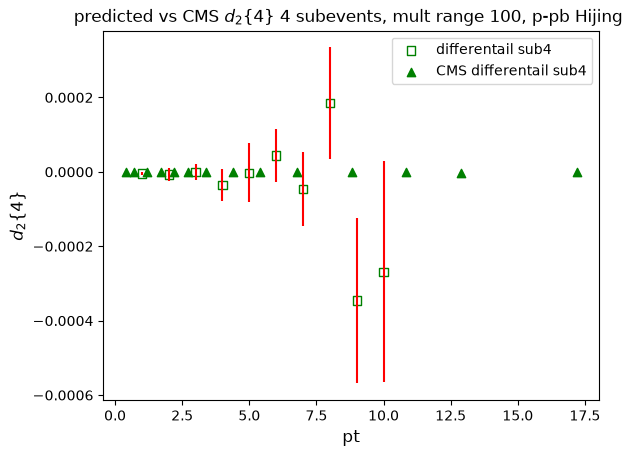

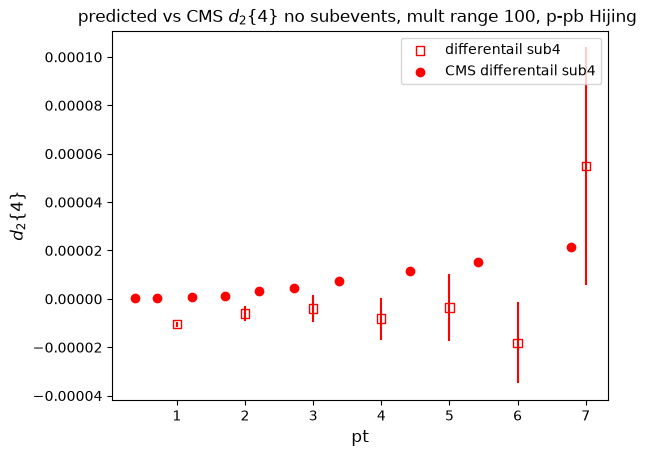

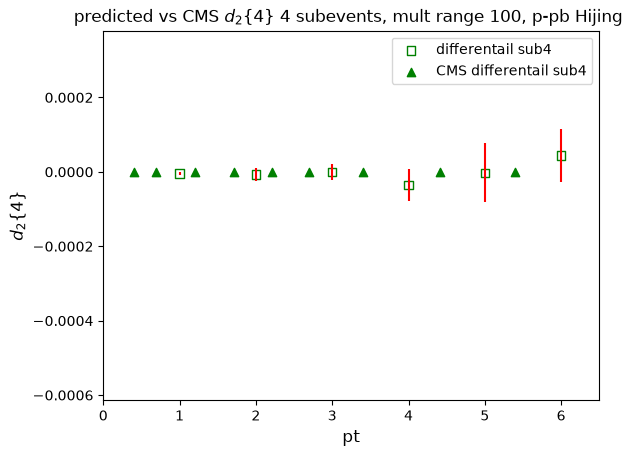

In [35]:
import matplotlib.pyplot as plt
x = np.linspace(1, 10, 10)
plt.figure(0)
plt.scatter(x, dcor4e4,  marker='s',  facecolors='none',edgecolors='green', label = 'differentail sub4')
plt.errorbar(x, dcor4e4, yerr = dcor4stde4, ecolor='red', linestyle='none' )
#data from graph 
plt.scatter(xcmsdcor4e4, ycmsdcor4e4,  marker='^',  color = 'green', label = 'CMS differentail sub4')
plt.title('predicted vs CMS $d_2\\{4\\}$ 4 subevents, mult range 100, p-pb Hijing ')
plt.ylabel("$d_2\\{4\\}$", fontsize = 12) 
plt.xlabel('pt', fontsize = 12)   
plt.legend()

x = np.linspace(1, 10, 10)
plt.figure(1)
plt.scatter(pt_bins, dcor4e0,  marker='s',  facecolors='none',edgecolors='red', label = 'differentail sub4')
plt.errorbar(pt_bins, dcor4e0, yerr = dcor4stde0, ecolor='red', linestyle='none' )
#data from graph
plt.scatter(xcmsdcor4e0, ycmsdcor4e0 ,  marker='o',  color = 'red', label = 'CMS differentail sub4')
plt.title('predicted vs CMS $d_2\\{4\\}$ no subevents, mult range 100, p-pb Hijing ')
plt.ylabel("$d_2\\{4\\}$", fontsize = 12) 
plt.xlabel('pt', fontsize = 12)   
plt.legend() 

x = np.linspace(1, 10, 10)
plt.figure(3)
plt.scatter(x, dcor4e4,  marker='s',  facecolors='none',edgecolors='green', label = 'differentail sub4')
plt.errorbar(x, dcor4e4, yerr = dcor4stde4, ecolor='red', linestyle='none' )
plt.xlim(0, 6.5)
#data from graph 
plt.scatter(xcmsdcor4e4, ycmsdcor4e4,  marker='^',  color = 'green', label = 'CMS differentail sub4')
plt.title('predicted vs CMS $d_2\\{4\\}$ 4 subevents, mult range 100, p-pb Hijing ')
plt.ylabel("$d_2\\{4\\}$", fontsize = 12) 
plt.xlabel('pt', fontsize = 12)   
plt.legend()

In [ ]:
def pt_binning(arr_list, mult_range, n, POI_start=1 , POI_end = 2, momentum_cut=0, nudge=False): arrs is phi, w, pt
    arrs = np.array(arr_list, dtype=object)

    # Vectorized extraction of lengths
    lengths = np.array([len(a[0]) for a in arr_list]) #lengths is mult
    

    mask = (lengths >= mult_range[0]) & (lengths <= mult_range[1])
    #print(mask)
    arrs = arrs[mask]

In [ ]:
phi_pt = phi[pt>.4]
for i in range(0, len(arrs[0]))

mult = np.array([len(a[0]) for a in arr_list])

In [1]:
pip install numpy                  

  Using cached numpy-2.5.3-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
Using cached numpy-2.5.3-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.7 MB)
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install matplotlib

  Using cached matplotlib-3.11.2-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (80 kB)
  Using cached contourpy-1.4.0-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.65.0-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (125 kB)
  Using cached kiwisolver-1.5.1-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.3.3-py3-none-any.whl.metadata (5.9 kB)
Using cached matplotlib-3.11.2-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (9.9 MB)
Using cached contourpy-1.4.0-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (384 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.65.0-cp313-cp313-manylinux2014_x86_64.manylinux_2_17

In [3]:
pip install uproot 

  Using cached uproot-5.7.6-py3-none-any.whl.metadata (36 kB)
  Using cached awkward-2.14.0-py3-none-any.whl.metadata (7.1 kB)
  Using cached cramjam-2.12.1-cp313-cp313-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (1.2 kB)
  Using cached fsspec-2026.9.0-py3-none-any.whl.metadata (10 kB)
  Using cached xxhash-4.0.1-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (17 kB)
  Using cached awkward_cpp-57-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (2.1 kB)
Using cached uproot-5.7.6-py3-none-any.whl (405 kB)
Using cached awkward-2.14.0-py3-none-any.whl (1.0 MB)
Using cached awkward_cpp-57-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (698 kB)
Using cached cramjam-2.12.1-cp313-cp313-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (2.0 MB)
Using cached fsspec-2026.9.0-py3-none-any.whl (221 kB)
Using cached xxhash-4.0.1-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (268 k

In [4]:
pip install pandas

  Using cached pandas-3.0.6-cp313-cp313-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
Using cached pandas-3.0.6-cp313-cp313-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (10.8 MB)
Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install statsmodels

  Using cached statsmodels-0.15.0-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (9.6 kB)
  Using cached scipy-1.18.1-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached patsy-1.0.3-py2.py3-none-any.whl.metadata (3.7 kB)
  Using cached formulaic-1.2.2-py3-none-any.whl.metadata (7.0 kB)
  Using cached interface_meta-2.0.1-py3-none-any.whl.metadata (6.4 kB)
  Using cached narwhals-2.26.0-py3-none-any.whl.metadata (15 kB)
  Using cached wrapt-2.4.2rc1-cp313-cp313-manylinux1_x86_64.manylinux_2_28_x86_64.manylinux_2_5_x86_64.whl.metadata (7.4 kB)
Using cached statsmodels-0.15.0-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (12.1 MB)
Using cached formulaic-1.2.2-py3-none-any.whl (118 kB)
Using cached interface_meta-2.0.1-py3-none-any.whl (15 kB)
Using cached narwhals-2.26.0-py3-none-any.whl (474 kB)
Using cached patsy-1.0.3-py2.py3-none-any.whl (233 kB)
Using cached scipy-1.18.1-cp313-cp313-manylinux_2_27_x86_64.many

In [11]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.
